#### Loading Libraries

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
from typing import List, Tuple
import os

import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Tuple
import numpy as np
import pandas as pd
from typing import List
from scipy.stats import linregress, skew, kurtosis
from scipy.signal import find_peaks
from statsmodels.tsa.stattools import acf
import antropy as ant
import nolds


import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Tuple
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.signal import spectrogram

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.signal import spectrogram
from scipy.ndimage import zoom
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import os
from typing import List, Tuple


#### Loading Data

In [3]:
"""
Data Loader - PaHaW Tasks 1-4
Load: Task 1=Spiral, Task 2=letter l, Task 3=bigram le, Task 4=word les
"""
class PaHaWLoader:
    """Load PaHaW data for tasks 1-4"""
    
    def __init__(self, root_dir: str, corpus_path: str):
        self.root_dir = Path(root_dir)
        self.corpus = pd.read_excel(corpus_path)
    
    def load_svc(self, filepath: str) -> pd.DataFrame:
        """Load .svc file"""
        with open(filepath, 'r') as f:
            n_samples = int(f.readline().strip())
        
        data = np.loadtxt(filepath, skiprows=1)
        df = pd.DataFrame(data, columns=[
            'y', 'x', 'timestamp', 'button', 'azimuth', 'altitude', 'pressure'
        ])
        return df
    
    def get_on_surface(self, df: pd.DataFrame) -> pd.DataFrame:
        """Extract on-surface movements (button=1)"""
        return df[df['button'] == 1].copy().reset_index(drop=True)
    
    def load_task(self, task_num: int) -> Tuple[List[pd.DataFrame], List[int], List[int]]:
        """
        Load all subjects for a task
        
        Args:
            task_num: 1=spiral, 2=letter l, 3=bigram le, 4=word les
        
        Returns:
            (data_list, labels, subject_ids)
        """
        data_list = []
        labels = []
        subject_ids = []
        
        for _, row in self.corpus.iterrows():
            subject_id = row['ID']
            label = 1 if row['Disease'] == 'PD' else 0
            
            # Find file
            subject_dir = self.root_dir / f"{subject_id:05d}"
            if not subject_dir.exists():
                continue
            
            pattern = f"{subject_id:05d}__{task_num}_*.svc"
            files = list(subject_dir.glob(pattern))
            
            if files:
                df = self.load_svc(str(files[0]))
                df_surface = self.get_on_surface(df)
                
                if len(df_surface) >= 10:
                    data_list.append(df_surface)
                    labels.append(label)
                    subject_ids.append(subject_id)
        
        print(f"Task {task_num}: Loaded {len(data_list)} samples "
              f"(PD={sum(labels)}, Healthy={len(labels)-sum(labels)})")
        
        return data_list, labels, subject_ids
    
    def get_subject_info(self, subject_id: int) -> dict:
        """Get subject metadata"""
        row = self.corpus[self.corpus['ID'] == subject_id]
        if len(row) == 0:
            return None
        
        row = row.iloc[0]
        return {
            'subject_id': subject_id,
            'disease': row['Disease'],
            'updrs': row.get('UPDRS', None),
            'age': row.get('Age', None)
        }


if __name__ == "__main__":
    loader = PaHaWLoader(
        root_dir=r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_public",
        corpus_path=r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"
    )
    
    # Test load
    for task in [1, 2,3]:
        data, labels, ids = loader.load_task(task)

Task 1: Loaded 72 samples (PD=36, Healthy=36)
Task 2: Loaded 75 samples (PD=37, Healthy=38)
Task 3: Loaded 75 samples (PD=37, Healthy=38)


#### Generate the images

In [32]:
"""
PaHaW SVC → GIF Generator  (timestamp-accurate)

Each GIF frame covers a fixed real-time window (FRAME_DURATION_MS).
Fast strokes draw quickly, slow/hesitant strokes draw slowly —
exactly as the subject wrote it.

Output structure:
    gifs/
        Task1_Spiral/
            PD/
            Normal/
        Task2_Letter_l/
            PD/
            Normal/
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd
import io

# ── Config ───────────────────────────────────────────────────────────────────
ROOT_DIR    = Path(r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_public")
CORPUS_PATH = Path(r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_files\corpus_PaHaW.xlsx")
OUTPUT_DIR  = Path("./gifs")

TASKS = {
    1: "Task1_Spiral",
    2: "Task2_Letter_l",
}

CFG = dict(
    # Each frame represents this many milliseconds of real drawing time.
    # Lower  → more frames, smoother, larger file, slower to generate.
    # 200 ms → ~5 fps feel but true speed; 100 ms → ~10 fps; 50 ms → ~20 fps
    frame_duration_ms = 200,

    img_size     = 500,
    dpi          = 100,
    line_width   = 2.0,
    line_color   = "black",
    bg_color     = "white",
    dot_color    = "#e63946",  # red tip dot; None to hide
    dot_size     = 60,
    progress_bar = True,
    loop         = 0,          # 0 = loop forever
)
# ─────────────────────────────────────────────────────────────────────────────


def load_svc(filepath: Path):
    """
    Load .svc → x, y arrays (normalised 0-1) and t in milliseconds.
    Only on-surface points (button == 1) are kept.
    """
    data   = np.loadtxt(filepath, skiprows=1)
    y_raw  = data[:, 0]
    x_raw  = data[:, 1]
    t_raw  = data[:, 2]   # raw tablet timestamp units
    button = data[:, 3]

    mask = button == 1
    x_raw, y_raw, t_raw = x_raw[mask], y_raw[mask], t_raw[mask]

    # The SVC timestamp column is in units of ~8 µs (125 Hz tablet).
    # Convert to milliseconds so frame_duration_ms is intuitive.
    # Δt between consecutive samples is ~8 ms → units are already ~ms.
    # We just zero-start and keep as-is; adjust the divisor if needed.
    t_ms = (t_raw - t_raw.min())          # zero-start, same units (~ms)

    y_raw = -y_raw  # flip: tablet top-left → bottom-left

    def norm(v):
        lo, hi = v.min(), v.max()
        return (v - lo) / (hi - lo) if hi > lo else np.zeros_like(v)

    return norm(x_raw), norm(y_raw), t_ms


def make_gif(x, y, t_ms, out_path: Path):
    img_size         = CFG["img_size"]
    dpi              = CFG["dpi"]
    frame_dur        = CFG["frame_duration_ms"]

    # Build frame boundaries from real timestamps
    t_max      = t_ms.max()
    frame_ends = np.arange(frame_dur, t_max + frame_dur, frame_dur)
    n_frames   = len(frame_ends)

    fig, ax = plt.subplots(figsize=(img_size / dpi, img_size / dpi), dpi=dpi)
    frames      = []
    durations   = []   # per-frame GIF delay in ms

    for i, t_end in enumerate(frame_ends):
        ax.cla()
        ax.set_facecolor(CFG["bg_color"])
        fig.patch.set_facecolor(CFG["bg_color"])
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.08, 1.05)
        ax.set_aspect("equal")
        ax.axis("off")

        idx = t_ms <= t_end
        xi, yi = x[idx], y[idx]

        if len(xi) > 1:
            ax.plot(xi, yi,
                    color=CFG["line_color"],
                    linewidth=CFG["line_width"],
                    solid_capstyle="round",
                    solid_joinstyle="round")

        if CFG["dot_color"] and len(xi) > 0:
            ax.scatter([xi[-1]], [yi[-1]],
                       s=CFG["dot_size"], c=CFG["dot_color"],
                       zorder=5, linewidths=0)

        if CFG["progress_bar"]:
            ax.plot([0, min(t_end, t_max) / t_max], [-0.055, -0.055],
                    color="#cccccc", linewidth=3,
                    solid_capstyle="butt",
                    transform=ax.transData, clip_on=False)

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi,
                    bbox_inches="tight", facecolor=CFG["bg_color"],
                    pad_inches=0.05)
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        buf.close()

        # Each GIF frame is shown for exactly frame_duration_ms
        durations.append(frame_dur)

    plt.close(fig)

    # PIL's duration param accepts a list → per-frame delays
    frames[0].save(
        out_path,
        save_all=True,
        append_images=frames[1:],
        optimize=False,
        duration=durations,   # ← list, one value per frame
        loop=CFG["loop"],
    )
    return n_frames


def main():
    corpus = pd.read_excel(CORPUS_PATH)
    total = ok = skipped = 0

    for task_num, task_name in TASKS.items():
        pd_dir     = OUTPUT_DIR / task_name / "PD"
        normal_dir = OUTPUT_DIR / task_name / "Normal"
        pd_dir.mkdir(parents=True, exist_ok=True)
        normal_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n{'='*60}")
        print(f"  Task {task_num}: {task_name}")
        print(f"{'='*60}")

        for _, row in corpus.iterrows():
            subject_id = int(row["ID"])
            label      = "PD" if row["Disease"] == "PD" else "Normal"
            save_dir   = pd_dir if label == "PD" else normal_dir

            subject_dir = ROOT_DIR / f"{subject_id:05d}"
            files = list(subject_dir.glob(f"{subject_id:05d}__{task_num}_*.svc"))

            total += 1
            if not files:
                print(f"  [{subject_id:05d}] SKIP – no file found")
                skipped += 1
                continue

            out_path = save_dir / f"{label}_{subject_id:05d}_task{task_num}.gif"

            try:
                x, y, t_ms = load_svc(files[0])
                if len(x) < 10:
                    print(f"  [{subject_id:05d}] SKIP – too few points ({len(x)})")
                    skipped += 1
                    continue

                n_frames = make_gif(x, y, t_ms, out_path)
                print(f"  [{subject_id:05d}] {label:6s}  {n_frames} frames  "
                      f"({t_ms.max()/1000:.1f}s real)  →  {out_path.name}")
                ok += 1

            except Exception as e:
                print(f"  [{subject_id:05d}] ERROR – {e}")
                skipped += 1

    print(f"\n{'='*60}")
    print(f"Done.  Generated: {ok}  |  Skipped: {skipped}  |  Total: {total}")
    print(f"Output: {OUTPUT_DIR.resolve()}")
    print(f"{'='*60}")


main()


  Task 1: Task1_Spiral
  [00001] PD      67 frames  (13.3s real)  →  PD_00001_task1.gif
  [00002] PD      91 frames  (18.2s real)  →  PD_00002_task1.gif
  [00003] PD      78 frames  (15.6s real)  →  PD_00003_task1.gif
  [00004] PD      110 frames  (22.0s real)  →  PD_00004_task1.gif
  [00005] PD      616 frames  (123.1s real)  →  PD_00005_task1.gif
  [00006] PD      107 frames  (21.3s real)  →  PD_00006_task1.gif
  [00007] PD      390 frames  (77.8s real)  →  PD_00007_task1.gif
  [00008] PD      47 frames  (9.3s real)  →  PD_00008_task1.gif
  [00009] PD      159 frames  (31.7s real)  →  PD_00009_task1.gif
  [00010] PD      147 frames  (29.3s real)  →  PD_00010_task1.gif
  [00013] PD      210 frames  (41.9s real)  →  PD_00013_task1.gif
  [00014] PD      106 frames  (21.0s real)  →  PD_00014_task1.gif
  [00015] PD      102 frames  (20.2s real)  →  PD_00015_task1.gif
  [00016] PD      21 frames  (4.1s real)  →  PD_00016_task1.gif
  [00017] PD      69 frames  (13.6s real)  →  PD_00017_tas

In [26]:
"""
Generate images from handwriting coordinates and save by class
"""


class HandwritingImageGenerator:
    """Generate images from handwriting coordinates"""
    
    def __init__(self, output_dir: str = './handwriting_images'):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True, parents=True)
        
        # Create task folders
        self.task_names = {
            1: 'Task1_Spiral',
            2: 'Task2_Letter_l',
            3: 'Task3_Bigram_le',
            4: 'Task4_Word_les'
        }
    
    def normalize_coordinates(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """
        Normalize coordinates to image space
        
        Args:
            df: DataFrame with 'x', 'y' columns
        
        Returns:
            Normalized x, y arrays
        """
        x = df['x'].values
        y = df['y'].values
        
        # Flip y-axis (image coordinates start from top-left)
        y = -y
        
        # Normalize to [0, 1]
        x_min, x_max = x.min(), x.max()
        y_min, y_max = y.min(), y.max()
        
        if x_max > x_min:
            x_norm = (x - x_min) / (x_max - x_min)
        else:
            x_norm = np.zeros_like(x)
        
        if y_max > y_min:
            y_norm = (y - y_min) / (y_max - y_min)
        else:
            y_norm = np.zeros_like(y)
        
        return x_norm, y_norm
    
    def generate_image_matplotlib(self, df: pd.DataFrame, img_size: int = 256,
                                 line_width: int = 3, background: str = 'white',
                                 line_color: str = 'black') -> np.ndarray:
        """
        Generate image using matplotlib (high quality)
        
        Args:
            df: DataFrame with coordinates
            img_size: Image size (square)
            line_width: Stroke width
            background: Background color
            line_color: Line color
        
        Returns:
            Image as numpy array (img_size, img_size, 3)
        """
        # Normalize coordinates
        x_norm, y_norm = self.normalize_coordinates(df)
        
        # Scale to image size with margin
        margin = 0.1
        scale = img_size * (1 - 2 * margin)
        offset = img_size * margin
        
        x_img = x_norm * scale + offset
        y_img = y_norm * scale + offset
        
        # Create figure
        fig, ax = plt.subplots(figsize=(img_size/100, img_size/100), dpi=100)
        
        # Plot trajectory
        ax.plot(x_img, y_img, color=line_color, linewidth=line_width, 
               solid_capstyle='round', solid_joinstyle='round')
        
        # Set background
        ax.set_facecolor(background)
        fig.patch.set_facecolor(background)
        
        # Remove axes
        ax.set_xlim(0, img_size)
        ax.set_ylim(0, img_size)
        ax.axis('off')
        ax.set_aspect('equal')
        
        # Convert to image
        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        
        plt.close(fig)
        
        return img
    
    def generate_image_opencv(self, df: pd.DataFrame, img_size: int = 256,
                             line_width: int = 3, background_color: tuple = (255, 255, 255),
                             line_color: tuple = (0, 0, 0)) -> np.ndarray:
        """
        Generate image using OpenCV (faster)
        
        Args:
            df: DataFrame with coordinates
            img_size: Image size (square)
            line_width: Stroke width
            background_color: Background RGB color
            line_color: Line RGB color
        
        Returns:
            Image as numpy array (img_size, img_size, 3)
        """
        # Create blank image
        img = np.full((img_size, img_size, 3), background_color, dtype=np.uint8)
        
        # Normalize coordinates
        x_norm, y_norm = self.normalize_coordinates(df)
        
        # Scale to image size with margin
        margin = 0.1
        scale = img_size * (1 - 2 * margin)
        offset = img_size * margin
        
        x_img = (x_norm * scale + offset).astype(int)
        y_img = (y_norm * scale + offset).astype(int)
        
        # Draw lines
        points = np.column_stack([x_img, y_img])
        
        for i in range(len(points) - 1):
            pt1 = tuple(points[i])
            pt2 = tuple(points[i + 1])
            cv2.line(img, pt1, pt2, line_color, line_width, cv2.LINE_AA)
        
        return img
    
    def save_image(self, img: np.ndarray, filepath: str):
        """Save image to file"""
        img_pil = Image.fromarray(img)
        img_pil.save(filepath)
    
    def generate_and_save_task_images(self, data_list: List[pd.DataFrame], 
                                     labels: List[int], subject_ids: List[int],
                                     task_num: int, img_size: int = 256,
                                     method: str = 'opencv', line_width: int = 3):
        """
        Generate and save images for a task
        
        Args:
            data_list: List of DataFrames with coordinates
            labels: List of labels (0=Healthy, 1=PD)
            subject_ids: List of subject IDs
            task_num: Task number (1-4)
            img_size: Image size
            method: 'matplotlib' or 'opencv'
            line_width: Stroke width
        """
        # Create task folder
        task_folder = self.output_dir / self.task_names[task_num]
        task_folder.mkdir(exist_ok=True, parents=True)
        
        # Create class subfolders
        pd_folder = task_folder / 'PD'
        normal_folder = task_folder / 'Normal'
        pd_folder.mkdir(exist_ok=True)
        normal_folder.mkdir(exist_ok=True)
        
        print(f"\n{'='*80}")
        print(f"Generating images for {self.task_names[task_num]}")
        print(f"{'='*80}")
        print(f"Total samples: {len(data_list)}")
        print(f"PD: {sum(labels)}, Normal: {len(labels) - sum(labels)}")
        print(f"Image size: {img_size}x{img_size}")
        print(f"Method: {method}")
        print(f"Output: {task_folder}")
        print()
        
        for idx, (df, label, subject_id) in enumerate(zip(data_list, labels, subject_ids)):
            # Determine class name and folder
            class_name = 'PD' if label == 1 else 'Normal'
            save_folder = pd_folder if label == 1 else normal_folder
            
            # Generate filename
            filename = f"{class_name}_{subject_id:05d}_task{task_num}.png"
            filepath = save_folder / filename
            
            # Generate image
            if method == 'matplotlib':
                img = self.generate_image_matplotlib(df, img_size=img_size, 
                                                     line_width=line_width)
            else:  # opencv
                img = self.generate_image_opencv(df, img_size=img_size, 
                                                line_width=line_width)
            
            # Save image
            self.save_image(img, str(filepath))
            
            if (idx + 1) % 10 == 0:
                print(f"✓ Generated {idx + 1}/{len(data_list)} images...")
        
        print(f"✓ All images saved to {task_folder}")
        print(f"  - PD images: {sum(labels)} in {pd_folder}")
        print(f"  - Normal images: {len(labels) - sum(labels)} in {normal_folder}")


print("✓ Image generator class defined!")

✓ Image generator class defined!


In [27]:
"""
Generate and save images for all tasks
"""
  # Assuming you saved the loader as pahaw_loader.py

# Initialize loader
loader = PaHaWLoader(
    root_dir=r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_public",
    corpus_path=r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"
)

# Initialize image generator
img_generator = HandwritingImageGenerator(
    output_dir=r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\handwriting_images"
)

# Generate images for each task
for task_num in [1, 2, 3, 4]:
    print(f"\n{'='*100}")
    print(f"PROCESSING TASK {task_num}")
    print(f"{'='*100}")
    
    # Load task data
    data_list, labels, subject_ids = loader.load_task(task_num)
    
    # Generate and save images
    img_generator.generate_and_save_task_images(
        data_list=data_list,
        labels=labels,
        subject_ids=subject_ids,
        task_num=task_num,
        img_size=256,  # 256x256 images
        method='opencv',  # 'opencv' is faster, 'matplotlib' is higher quality
        line_width=3
    )

print("\n" + "="*100)
print("✓ ALL TASKS COMPLETE!")
print("="*100)


PROCESSING TASK 1
Task 1: Loaded 72 samples (PD=36, Healthy=36)

Generating images for Task1_Spiral
Total samples: 72
PD: 36, Normal: 36
Image size: 256x256
Method: opencv
Output: C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\handwriting_images\Task1_Spiral

✓ Generated 10/72 images...
✓ Generated 20/72 images...
✓ Generated 30/72 images...
✓ Generated 40/72 images...
✓ Generated 50/72 images...
✓ Generated 60/72 images...
✓ Generated 70/72 images...
✓ All images saved to C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\handwriting_images\Task1_Spiral
  - PD images: 36 in C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\handwriting_images\Task1_Spiral\PD
  - Normal images: 36 in C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\handwriting_images\Task1_Spiral\Normal

PROCESSING TASK 2
Task 2: Loaded 75 samples (PD=37, Healthy=38)

Generating images for Task2_Letter_l
Total samples: 75
PD: 37, Normal: 38
Image size: 256x

#### ML Features & Classification   (EXtra)

In [4]:
"""
PaHaW Handwriting PD Classification
Feature Extraction + 10-Fold CV
No ablation — all features used
Prints final results with best hyperparameters per family
"""

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, iqr
from scipy.signal import find_peaks
from scipy.stats import linregress
from typing import Dict
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


# =============================================================================
# FEATURE EXTRACTION
# =============================================================================

def compute_features(df) -> Dict[str, float]:
    timestamps = df['timestamp'].values
    x          = df['x'].values
    y          = df['y'].values
    pressure   = df['pressure'].values

    dt = np.maximum(np.diff(timestamps) / 1000.0, 1e-6)
    dx = np.diff(x)
    dy = np.diff(y)

    vel_x    = dx / dt
    vel_y    = dy / dt
    velocity = np.sqrt(vel_x**2 + vel_y**2)
    accel    = np.diff(velocity) / dt[:-1]
    jerk     = np.diff(accel) / dt[:-2]
    dp       = np.diff(pressure.astype(float))
    pressure_rate = dp / dt

    feats = {}

    # Velocity X
    # feats.update({
    #     'vel_x_mean': float(np.mean(vel_x)),
    #     'vel_x_std':  float(np.std(vel_x)),
    #     'vel_x_skew': float(skew(vel_x)),
    #     'vel_x_kurt': float(kurtosis(vel_x)),
    # })

    # # Velocity Y
    # feats.update({
    #     'vel_y_mean': float(np.mean(vel_y)),
    #     'vel_y_std':  float(np.std(vel_y)),
    #     'vel_y_skew': float(skew(vel_y)),
    #     'vel_y_kurt': float(kurtosis(vel_y)),
    # })

    # Velocity magnitude
    feats.update({
        'vel_mean':   float(np.mean(velocity)),
        'vel_std':    float(np.std(velocity)),
        'vel_cv':     float(np.std(velocity) / (np.mean(velocity) + 1e-10)),
        # 'vel_median': float(np.median(velocity)),
        # 'vel_iqr':    float(iqr(velocity)),
        # 'vel_skew':   float(skew(velocity)),
        # 'vel_kurt':   float(kurtosis(velocity)),
        # 'vel_range':  float(np.max(velocity) - np.min(velocity)),
    })

    # Acceleration
    feats.update({
        'acc_mean': float(np.mean(accel)),
        'acc_std':  float(np.std(accel)),
        # 'acc_cv':   float(np.std(accel) / (np.mean(np.abs(accel)) + 1e-10)),
        # 'acc_skew': float(skew(accel)),
        # 'acc_kurt': float(kurtosis(accel)),
        # 'acc_iqr':  float(iqr(accel)),
        # 'acc_rms':  float(np.sqrt(np.mean(accel**2))),
    })

    # Jerk
    feats.update({
        'jerk_mean': float(np.mean(jerk)),
        'jerk_std':  float(np.std(jerk)),
        # 'jerk_rms':  float(np.sqrt(np.mean(jerk**2))),
        # 'jerk_iqr':  float(iqr(jerk)),
    })

    # Pressure
    feats.update({
        'pressure_mean':     float(np.mean(pressure)),
        'pressure_std':      float(np.std(pressure)),
    #     'pressure_cv':       float(np.std(pressure) / (np.mean(pressure) + 1e-10)),
    #     'pressure_skew':     float(skew(pressure)),
    #     'pressure_kurt':     float(kurtosis(pressure)),
    #     'pressure_rate_std': float(np.std(pressure_rate)),
    })

    # Temporal trends
    n_acc  = len(accel)
    q      = max(n_acc // 4, 1)
    n_vel  = len(velocity)
    q_vel  = max(n_vel // 4, 1)
    slope, _, r_value, _, _ = linregress(np.arange(n_vel), velocity)
    feats.update({
        'acc_start_vs_end': float(np.mean(accel[:q]) - np.mean(accel[-q:])),
        'vel_start_vs_end': float(np.mean(velocity[:q_vel]) - np.mean(velocity[-q_vel:])),
        'vel_trend_slope':  float(slope),
        'vel_trend_r2':     float(r_value**2),
    })

    # Rhythm / oscillation
    velocity_diffs = np.diff(velocity)
    mean_vel       = np.mean(velocity)
    zero_crossings = np.sum(np.abs(np.diff(np.sign(velocity - mean_vel))) > 0)
    peaks,   _     = find_peaks(velocity)
    troughs, _     = find_peaks(-velocity)
    feats.update({
        'vel_mono_dec':    float(np.sum(velocity_diffs < 0) / len(velocity_diffs)),
        #'vel_zcr':         float(zero_crossings / len(velocity)),
        'vel_peak_rate':   float(len(peaks)   / len(velocity)),
        'vel_trough_rate': float(len(troughs) / len(velocity)),
        'vel_peak_std':    float(np.std(velocity[peaks]) if len(peaks) > 1 else 0.0),
    })

    # Local variability
    window_size = max(10, len(velocity) // 10)
    n_windows   = len(velocity) // window_size
    if n_windows >= 3:
        local_means = [np.mean(velocity[i*window_size:(i+1)*window_size]) for i in range(n_windows)]
        local_stds  = [np.std(velocity[i*window_size:(i+1)*window_size])  for i in range(n_windows)]
        slope_var, _, _, _, _ = linregress(np.arange(len(local_stds)), local_stds)
        feats.update({
            'vel_local_mean_std': float(np.std(local_means)),
            'vel_var_trend':      float(slope_var),
            'vel_local_cv_mean':  float(np.mean([s/(m+1e-10) for s, m in zip(local_stds, local_means)])),
        })
    else:
        feats.update({'vel_local_mean_std': 0.0, 'vel_var_trend': 0.0, 'vel_local_cv_mean': 0.0})

    # Global
    path_length = np.sum(np.sqrt(dx**2 + dy**2))
    total_time  = (timestamps[-1] - timestamps[0]) / 1000.0
    feats.update({
        'total_time':        float(total_time),
        'total_path_length': float(path_length),
        'mean_speed':        float(path_length / (total_time + 1e-10)),
    })

    return feats


def build_feature_matrix(data_list, labels, subject_ids):
    rows = []
    for df, label, sid in zip(data_list, labels, subject_ids):
        try:
            feats = compute_features(df)
            feats['subject_id'] = sid
            feats['label']      = label
            rows.append(feats)
        except Exception as e:
            print(f"  Warning: Skipped {sid} — {e}")
    return pd.DataFrame(rows).fillna(0)


# =============================================================================
# MODEL CONFIGS  (all hyperparameter variants)
# =============================================================================

def get_all_configs():
    return {
        # SVM
        'SVM_C1':        Pipeline([('s', StandardScaler()), ('m', SVC(kernel='rbf', C=1,   gamma='scale',  probability=True, random_state=42))]),
        'SVM_C10':       Pipeline([('s', StandardScaler()), ('m', SVC(kernel='rbf', C=10,  gamma='scale',  probability=True, random_state=42))]),
        'SVM_C100':      Pipeline([('s', StandardScaler()), ('m', SVC(kernel='rbf', C=100, gamma='scale',  probability=True, random_state=42))]),
        'SVM_C10_g01':   Pipeline([('s', StandardScaler()), ('m', SVC(kernel='rbf', C=10,  gamma=0.01,     probability=True, random_state=42))]),
        'SVM_C100_g001': Pipeline([('s', StandardScaler()), ('m', SVC(kernel='rbf', C=100, gamma=0.001,    probability=True, random_state=42))]),
        # KNN
        'KNN_3':         Pipeline([('s', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan'))]),
        'KNN_5':         Pipeline([('s', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=5, weights='distance', metric='manhattan'))]),
        'KNN_7':         Pipeline([('s', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean'))]),
        # FFN
        'FFN_64_32':     Pipeline([('s', StandardScaler()), ('m', MLPClassifier(hidden_layer_sizes=(64, 32),  activation='relu', solver='adam', learning_rate_init=0.001,  max_iter=500, early_stopping=True, validation_fraction=0.15, n_iter_no_change=20, random_state=42))]),
        'FFN_32':        Pipeline([('s', StandardScaler()), ('m', MLPClassifier(hidden_layer_sizes=(32,),     activation='relu', solver='adam', learning_rate_init=0.001,  max_iter=500, early_stopping=True, validation_fraction=0.15, n_iter_no_change=20, random_state=42))]),
        'FFN_128_64':    Pipeline([('s', StandardScaler()), ('m', MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', learning_rate_init=0.0005, alpha=0.01, max_iter=500, early_stopping=True, validation_fraction=0.15, n_iter_no_change=20, random_state=42))]),
        # XGBoost
        'XGB_d3_lr01':   XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,  random_state=42, eval_metric='logloss'),
        'XGB_d5_lr01':   XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,  random_state=42, eval_metric='logloss'),
        'XGB_d3_lr005':  XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss'),
        'XGB_d2_lr03':   XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.3,  random_state=42, eval_metric='logloss'),
    }


def describe_config(name, config):
    """Return a human-readable hyperparameter string for a config."""
    if name.startswith('SVM'):
        m = config.named_steps['m']
        return f"kernel=rbf, C={m.C}, gamma={m.gamma}"
    elif name.startswith('KNN'):
        m = config.named_steps['m']
        return f"k={m.n_neighbors}, weights={m.weights}, metric={m.metric}"
    elif name.startswith('FFN'):
        m = config.named_steps['m']
        lr = m.learning_rate_init
        alpha = getattr(m, 'alpha', 0.0001)
        return f"layers={m.hidden_layer_sizes}, lr={lr}, alpha={alpha}"
    elif name.startswith('XGB'):
        return f"n_estimators={config.n_estimators}, max_depth={config.max_depth}, lr={config.learning_rate}"
    return ""


# =============================================================================
# CLASSIFICATION  (10-Fold CV, all configs, best per family + ensemble)
# =============================================================================

def classify(df):
    feature_cols = [c for c in df.columns if c not in ['subject_id', 'label']]
    X = df[feature_cols].values
    y = df['label'].values

    print(f"  Subjects : {len(X)}  |  Features : {len(feature_cols)}")
    print(f"  Class dist — PD: {(y==1).sum()}  HC: {(y==0).sum()}")

    cv      = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    configs = get_all_configs()

    # ── Evaluate all configs ──────────────────────────────────────────────────
    all_results = {}
    for name, model in configs.items():
        fold_accs, fold_f1s = [], []
        for train_idx, test_idx in cv.split(X, y):
            m = clone(model)
            m.fit(X[train_idx], y[train_idx])
            y_pred = m.predict(X[test_idx])
            fold_accs.append(accuracy_score(y[test_idx], y_pred) * 100)
            fold_f1s.append(f1_score(y[test_idx], y_pred, average='macro') * 100)
        all_results[name] = {
            'mean_acc': np.mean(fold_accs),
            'std_acc':  np.std(fold_accs),
            'mean_f1':  np.mean(fold_f1s),
            'std_f1':   np.std(fold_f1s),
        }

    # ── Best per family ───────────────────────────────────────────────────────
    families = {
        'SVM':     [k for k in all_results if k.startswith('SVM')],
        'KNN':     [k for k in all_results if k.startswith('KNN')],
        'FFN':     [k for k in all_results if k.startswith('FFN')],
        'XGBoost': [k for k in all_results if k.startswith('XGB')],
    }
    best_per_family = {}
    for family, cfgs in families.items():
        best_name = max(cfgs, key=lambda k: all_results[k]['mean_acc'])
        best_per_family[family] = (best_name, all_results[best_name])

    # ── Ensemble with best per family ─────────────────────────────────────────
    best_models = {family: configs[name] for family, (name, _) in best_per_family.items()}
    ens_accs, ens_f1s = [], []
    all_y_true, all_y_pred = [], []

    for train_idx, test_idx in cv.split(X, y):
        trained = {f: clone(m).fit(X[train_idx], y[train_idx]) for f, m in best_models.items()}
        ens = VotingClassifier(
            estimators=[(f.lower(), m) for f, m in trained.items()], voting='soft'
        )
        ens.fit(X[train_idx], y[train_idx])
        y_pred = ens.predict(X[test_idx])
        ens_accs.append(accuracy_score(y[test_idx], y_pred) * 100)
        ens_f1s.append(f1_score(y[test_idx], y_pred, average='macro') * 100)
        all_y_true.extend(y[test_idx])
        all_y_pred.extend(y_pred)

    all_results['Ensemble'] = {
        'mean_acc': np.mean(ens_accs), 'std_acc': np.std(ens_accs),
        'mean_f1':  np.mean(ens_f1s),  'std_f1':  np.std(ens_f1s),
    }
    cm = confusion_matrix(all_y_true, all_y_pred)

    return all_results, best_per_family, cm, configs


# =============================================================================
# PRINT RESULTS
# =============================================================================

def print_results(task, all_results, best_per_family, cm, configs):
    print(f"\n{'='*70}")
    print(f"  TASK {task} — RESULTS")
    print(f"{'='*70}")

    # All configs sorted
    print(f"\n  {'Config':<20} {'Acc Mean':>10} {'± Std':>8} {'F1 Mean':>10} {'± Std':>8}")
    print(f"  {'-'*60}")
    for name, scores in sorted(all_results.items(), key=lambda x: -x[1]['mean_acc']):
        print(f"  {name:<20} {scores['mean_acc']:>9.2f}% {scores['std_acc']:>7.2f}%"
              f" {scores['mean_f1']:>9.2f}% {scores['std_f1']:>7.2f}%")

    # Best per family with hyperparameters
    print(f"\n  {'--- Best per Family (with Hyperparameters) ---'}")
    print(f"  {'-'*70}")
    for family, (config_name, scores) in best_per_family.items():
        params = describe_config(config_name, configs[config_name])
        print(f"  {family:<10} | {config_name:<20} | Acc: {scores['mean_acc']:.2f}% ± {scores['std_acc']:.2f}%"
              f"  F1: {scores['mean_f1']:.2f}%")
        print(f"             | Params: {params}")

    # Ensemble
    ens = all_results['Ensemble']
    print(f"\n  {'Ensemble':<10} | best SVM + KNN + FFN + XGBoost (soft voting)")
    print(f"             | Acc: {ens['mean_acc']:.2f}% ± {ens['std_acc']:.2f}%"
          f"  F1: {ens['mean_f1']:.2f}%")

    # Confusion matrix
    print(f"\n  Confusion Matrix (aggregate over all folds):")
    print(f"               Pred PD   Pred HC")
    print(f"  True PD   :  {cm[1,1]:>6}    {cm[1,0]:>6}")
    print(f"  True HC   :  {cm[0,1]:>6}    {cm[0,0]:>6}")


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":

    loader = PaHaWLoader(
        root_dir=r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_public",
        corpus_path=r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"
    )

    print("=" * 70)
    print("PaHaW — PD Handwriting Classification")
    print("All features | 10-Fold Stratified CV | Multi-config search")
    print("=" * 70)

    summary_rows = []

    for task in [1, 2, 3]:
        print(f"\nLoading Task {task}...")
        data, labels, ids = loader.load_task(task)

        df = build_feature_matrix(data, labels, ids)
        print(f"  Feature matrix: {df.shape}")

        all_results, best_per_family, cm, configs = classify(df)
        print_results(task, all_results, best_per_family, cm, configs)

        row = {'Task': task}
        for family, (config_name, scores) in best_per_family.items():
            row[f'{family}_Config'] = config_name
            row[f'{family}_Acc']    = round(scores['mean_acc'], 2)
            row[f'{family}_F1']     = round(scores['mean_f1'],  2)
        row['Ensemble_Acc'] = round(all_results['Ensemble']['mean_acc'], 2)
        row['Ensemble_F1']  = round(all_results['Ensemble']['mean_f1'],  2)
        summary_rows.append(row)

    # ── Final Summary Table ───────────────────────────────────────────────────
    print(f"\n\n{'='*70}")
    print("FINAL SUMMARY — Best per Family across Tasks")
    print(f"{'='*70}")

    summary = pd.DataFrame(summary_rows)

    print(f"\n  {'Family':<12}", end='')
    for task in [1, 2, 3]:
        print(f"  {'Task'+str(task)+' Acc':>12}  {'Task'+str(task)+' F1':>10}", end='')
    print(f"  {'Avg Acc':>10}")
    print(f"  {'-'*80}")

    for family in ['SVM', 'KNN', 'FFN', 'XGBoost', 'Ensemble']:
        col = f'{family}_Acc'
        f1_col = f'{family}_F1'
        print(f"  {family:<12}", end='')
        vals = []
        for task in [1, 2, 3]:
            row = summary[summary['Task'] == task].iloc[0]
            acc = row[col]
            f1  = row[f1_col]
            vals.append(acc)
            print(f"  {acc:>11.2f}%  {f1:>9.2f}%", end='')
        print(f"  {np.mean(vals):>9.2f}%")

    summary.to_csv('handwriting_classification_results.csv', index=False)
    print(f"\n  Results saved → handwriting_classification_results.csv")
    print(f"\n{'='*70}")
    print("Done!")
    print(f"{'='*70}")

PaHaW — PD Handwriting Classification
All features | 10-Fold Stratified CV | Multi-config search

Loading Task 1...
Task 1: Loaded 72 samples (PD=36, Healthy=36)
  Feature matrix: (72, 25)
  Subjects : 72  |  Features : 23
  Class dist — PD: 36  HC: 36

  TASK 1 — RESULTS

  Config                 Acc Mean    ± Std    F1 Mean    ± Std
  ------------------------------------------------------------
  SVM_C100_g001            59.82%   12.04%     56.98%   14.39%
  SVM_C10_g01              59.46%    8.38%     57.12%    8.37%
  KNN_7                    58.39%   12.22%     54.51%   13.61%
  KNN_3                    58.04%   11.66%     55.99%   11.26%
  SVM_C1                   58.04%    9.76%     55.79%    9.22%
  XGB_d5_lr01              54.46%   10.87%     51.75%    9.36%
  FFN_128_64               54.11%   20.17%     49.98%   21.50%
  FFN_32                   53.39%   19.83%     49.87%   21.57%
  KNN_5                    52.68%    7.02%     49.62%    9.09%
  XGB_d3_lr005             51.96%

#### Spectogram through DL Models

In [11]:
def compute_velocity(df: pd.DataFrame) -> np.ndarray:
    """Compute velocity from trajectory"""
    timestamps = df['timestamp'].values
    x = df['x'].values
    y = df['y'].values
    
    dt = np.diff(timestamps) / 1000.0
    dt = np.maximum(dt, 1e-6)
    
    dx = np.diff(x)
    dy = np.diff(y)
    
    velocity = np.sqrt(dx**2 + dy**2) / dt
    
    return velocity


def compute_spectrogram(signal: np.ndarray, nperseg: int = 32, noverlap: int = 16, 
                        target_freq: int = 32, target_time: int = 32) -> np.ndarray:
    """
    Compute spectrogram and resize to fixed dimensions
    Output: (target_freq, target_time)
    """
    if len(signal) < nperseg:
        signal = np.pad(signal, (0, nperseg - len(signal)), mode='constant')
    
    f, t, Sxx = spectrogram(signal, fs=100, nperseg=nperseg, noverlap=noverlap)
    
    Sxx = np.log1p(Sxx)
    
    if Sxx.shape[0] == 0 or Sxx.shape[1] == 0:
        return np.zeros((target_freq, target_time))
    
    zoom_factors = (target_freq / Sxx.shape[0], target_time / Sxx.shape[1])
    Sxx_resized = zoom(Sxx, zoom_factors, order=1)
    
    return Sxx_resized


def extract_spectrogram(df: pd.DataFrame, target_freq: int = 32, 
                        target_time: int = 32) -> np.ndarray:
    """
    Extract velocity spectrogram
    Output shape: (target_freq, target_time, 1)
    """
    velocity = compute_velocity(df)
    
    spec = compute_spectrogram(velocity, target_freq=target_freq, target_time=target_time)
    
    # Add channel dimension: (freq, time, 1) - TensorFlow format
    spec = np.expand_dims(spec, axis=-1)
    
    return spec


def prepare_data(data_list: List[pd.DataFrame], labels: List[int], 
                 target_freq: int = 32, target_time: int = 32):
    """Prepare spectrogram data"""
    spectrograms = []
    
    for df in data_list:
        spec = extract_spectrogram(df, target_freq, target_time)
        spectrograms.append(spec)
    
    X = np.array(spectrograms, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    
    # Normalize
    mean = X.mean()
    std = X.std() + 1e-6
    X = (X - mean) / std
    
    return X, y

## Models

#### LSTMConv (V1)

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =============================================================================
# CONVLSTM2D MODEL — handwriting
# Consistent with FlipFlop (same modality) and with finger-tapping / speech /
# gait spec-branch: Permute -> Reshape -> Recurrent -> Flatten -> Dense(64)
# =============================================================================
def build_convlstm_model(input_shape=(32, 32, 1), filters=32, dropout=0.1):
    """
    Build ConvLSTM2D model.

    Input: (freq, time, 1) — single-channel velocity spectrogram.

    Flow:
      Permute  (freq, time, 1) -> (time, freq, 1)      # time is now axis 0
      Reshape                   -> (time, freq, 1, 1)   # add width dim for ConvLSTM2D
      ConvLSTM2D(f=32, 3x3)     -> (freq, 1, 32)        # return_sequences=False
      Flatten                   -> (1024,)              # 32*1*32 -- NO GAP
      Dense(64, ReLU) -> Dropout -> Dense(2, Softmax)
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Put time first so ConvLSTM iterates along time axis.
        # (freq, time, 1) -> (time, freq, 1)
        layers.Permute((2, 1, 3)),

        # Add width=1 dim so ConvLSTM2D sees (time, H, W, C) = (32, 32, 1, 1)
        layers.Reshape((input_shape[1], input_shape[0], 1, 1)),

        # Sequential processing across the 32 time steps
        layers.ConvLSTM2D(
            filters=filters,
            kernel_size=(3, 3),
            padding='same',
            return_sequences=False,
            activation='tanh',
        ),

        # Flatten (replaces GlobalAveragePooling2D to match other modalities)
        layers.Flatten(),

        # Dense head
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(2, activation='softmax'),
    ], name='ConvLSTM2D_Classifier')

    return model


In [16]:
import pickle
import json

# =============================================================================
# TRAINING WITH TEST DATA TRACKING
# =============================================================================
def train_fold(X_train, y_train, X_test, y_test, fold, task, 
               train_idx, test_idx, subject_ids,
               model_dir, epochs=100, batch_size=4):
    """Train single fold and save test indices"""
    
    # Build model
    model = build_convlstm_model(input_shape=X_train.shape[1:])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    fold_dir = os.path.join(model_dir, f'fold_{fold}')
    os.makedirs(fold_dir, exist_ok=True)
    
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            os.path.join(fold_dir, 'best_model.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=40,
            restore_best_weights=True,
            verbose=0
        )
    ]
    
    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    
    # Save last model
    model.save(os.path.join(fold_dir, 'last_model.h5'))
    
    # CRITICAL: Save test data and indices
    np.save(os.path.join(fold_dir, 'X_test.npy'), X_test)
    np.save(os.path.join(fold_dir, 'y_test.npy'), y_test)
    np.save(os.path.join(fold_dir, 'test_indices.npy'), test_idx)
    
    # Save test subject IDs
    test_subject_ids = [subject_ids[i] for i in test_idx]
    with open(os.path.join(fold_dir, 'test_subject_ids.json'), 'w') as f:
        json.dump(test_subject_ids, f)
    
    # Save fold metadata
    metadata = {
        'fold': fold,
        'task': task,
        'train_size': len(X_train),
        'test_size': len(X_test),
        'test_indices': test_idx.tolist(),
        'test_subject_ids': test_subject_ids,
        'input_shape': X_train.shape[1:],
        'best_epoch': int(np.argmax(history.history['val_accuracy']) + 1)
    }
    with open(os.path.join(fold_dir, 'metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)
    
    # Evaluate
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    test_acc = (y_pred == y_test).mean()
    
    best_val_acc = max(history.history['val_accuracy'])
    last_val_acc = history.history['val_accuracy'][-1]
    
    return y_pred, best_val_acc, last_val_acc, test_acc, history


# =============================================================================
# REPRODUCTION FUNCTION
# =============================================================================
def reproduce_results(fold_dir, model_type='best'):
    """
    Reproduce results from saved model and test data
    
    Args:
        fold_dir: Path to fold directory (e.g., 'models_task1/fold_1')
        model_type: 'best' or 'last'
    
    Returns:
        Dictionary with predictions, true labels, confusion matrix, etc.
    """
    
    # Load metadata
    with open(os.path.join(fold_dir, 'metadata.json'), 'r') as f:
        metadata = json.load(f)
    
    print(f"Fold {metadata['fold']} - Task {metadata['task']}")
    print(f"Test samples: {metadata['test_size']}")
    print(f"Test subject IDs: {metadata['test_subject_ids']}")
    
    # Load model
    model_path = os.path.join(fold_dir, f'{model_type}_model.h5')
    model = keras.models.load_model(model_path)
    print(f"\nLoaded {model_type} model from: {model_path}")
    
    # Load test data
    X_test = np.load(os.path.join(fold_dir, 'X_test.npy'))
    y_test = np.load(os.path.join(fold_dir, 'y_test.npy'))
    
    print(f"Test data shape: {X_test.shape}")
    
    # Predict
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    
    # Compute metrics
    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
    
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Healthy', 'PD'])
    
    print(f"\nTest Accuracy: {acc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{report}")
    
    results = {
        'fold': metadata['fold'],
        'task': metadata['task'],
        'model_type': model_type,
        'test_subject_ids': metadata['test_subject_ids'],
        'y_true': y_test,
        'y_pred': y_pred,
        'confusion_matrix': cm,
        'accuracy': acc,
        'metadata': metadata
    }
    
    return results


# =============================================================================
# REPRODUCE ALL FOLDS FOR A TASK
# =============================================================================
def reproduce_all_folds(task, model_dir='models_task1', model_type='best'):
    """Reproduce results for all folds of a task"""
    
    print(f"\n{'='*70}")
    print(f"REPRODUCING RESULTS - TASK {task} - {model_type.upper()} MODEL")
    print('='*70)
    
    all_results = []
    
    for fold in range(1, 11):  # 5 folds
        fold_dir = os.path.join(model_dir, f'fold_{fold}')
        
        if not os.path.exists(fold_dir):
            print(f"\nFold {fold}: Directory not found")
            continue
        
        print(f"\n{'-'*70}")
        results = reproduce_results(fold_dir, model_type)
        all_results.append(results)
    
    # Aggregate results
    print(f"\n{'='*70}")
    print(f"AGGREGATE RESULTS - TASK {task}")
    print('='*70)
    
    accs = [r['accuracy'] for r in all_results]
    print(f"Mean Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    
    # Aggregate confusion matrix
    total_cm = sum([r['confusion_matrix'] for r in all_results])
    print(f"\nAggregated Confusion Matrix:\n{total_cm}")
    
    return all_results


In [17]:
# =============================================================================
# MAIN TRAINING CODE (UPDATED)
# =============================================================================
if __name__ == "__main__":
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import confusion_matrix, classification_report
    
    # Config
    ROOT_DIR = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_public"
    CORPUS_PATH = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"
    
    TARGET_FREQ = 32
    TARGET_TIME = 32
    BATCH_SIZE = 4
    EPOCHS = 100
    N_FOLDS = 10
    
    print(f"TensorFlow version: {tf.__version__}")
    print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
    
    loader = PaHaWLoader(ROOT_DIR, CORPUS_PATH)
    
    for task in [1, 2, 3]:
        print(f"\n{'='*70}")
        print(f"TASK {task}")
        print('='*70)
        
        # Load data
        data_list, labels, ids = loader.load_task(task)
        
        # Prepare spectrograms
        print("Extracting spectrograms...")
        X, y = prepare_data(data_list, labels, TARGET_FREQ, TARGET_TIME)
        
        print(f"Data shape: {X.shape}")
        print(f"Class distribution: {np.bincount(y)}")
        
        # 5-fold cross-validation
        model_dir = f'models_task_convlstm_v2{task}'
        os.makedirs(model_dir, exist_ok=True)
        
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        
        fold_results = []
        all_histories = []
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            print(f"\nFold {fold}/{N_FOLDS}")
            print("-" * 50)
            
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            print(f"Train: {len(X_train)}, Test: {len(X_test)}")
            
            # Train - UPDATED with indices and subject_ids
            y_pred, best_acc, last_acc, test_acc, history = train_fold(
                X_train, y_train, X_test, y_test, 
                fold, task, train_idx, test_idx, ids,  # Added these
                model_dir, epochs=EPOCHS, batch_size=BATCH_SIZE
            )
            
            all_histories.append(history)
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            
            print(f"Best val acc: {best_acc:.4f}")
            print(f"Last epoch acc: {last_acc:.4f}")
            print(f"Test acc: {test_acc:.4f}")
            print(f"Confusion Matrix:\n{cm}")
            
            fold_results.append({
                'fold': fold,
                'best_acc': best_acc,
                'last_acc': last_acc,
                'test_acc': test_acc,
                'cm': cm
            })
        
        # Plot average curves
        #plot_average_curves(all_histories, model_dir, task)
        
        # Summary
        print(f"\n{'='*70}")
        print(f"TASK {task} SUMMARY")
        print('='*70)
        
        best_accs = [r['best_acc'] for r in fold_results]
        last_accs = [r['last_acc'] for r in fold_results]
        test_accs = [r['test_acc'] for r in fold_results]
        
        print(f"Average best val acc: {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")
        print(f"Average last epoch acc: {np.mean(last_accs):.4f} ± {np.std(last_accs):.4f}")
        print(f"Average test acc: {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
        
        # Aggregate confusion matrix
        total_cm = sum([r['cm'] for r in fold_results])
        print(f"\nAggregated Confusion Matrix:\n{total_cm}")



TensorFlow version: 2.17.0
GPU available: False

TASK 1
Task 1: Loaded 72 samples (PD=36, Healthy=36)
Extracting spectrograms...
Data shape: (72, 32, 32, 1)
Class distribution: [36 36]

Fold 1/10
--------------------------------------------------
Train: 64, Test: 8


Best val acc: 0.6250
Last epoch acc: 0.2500
Test acc: 0.6250
Confusion Matrix:
[[4 0]
 [3 1]]

Fold 2/10
--------------------------------------------------
Train: 64, Test: 8


Best val acc: 0.7500
Last epoch acc: 0.7500
Test acc: 0.7500
Confusion Matrix:
[[3 1]
 [1 3]]

Fold 3/10
--------------------------------------------------
Train: 65, Test: 7


Best val acc: 0.8571
Last epoch acc: 0.7143
Test acc: 0.8571
Confusion Matrix:
[[3 0]
 [1 3]]

Fold 4/10
--------------------------------------------------
Train: 65, Test: 7


Best val acc: 0.5714
Last epoch acc: 0.5714
Test acc: 0.5714
Confusion Matrix:
[[3 0]
 [3 1]]

Fold 5/10
--------------------------------------------------
Train: 65, Test: 7


...

Best val acc: 0.7143
Last epoch acc: 0.5714
Test acc: 0.7143
Confusion Matrix:
[[3 0]
 [2 2]]

Fold 7/10
--------------------------------------------------
Train: 68, Test: 7


Best val acc: 0.7143
Last epoch acc: 0.2857
Test acc: 0.7143
Confusion Matrix:
[[2 1]
 [1 3]]

Fold 8/10
--------------------------------------------------
Train: 68, Test: 7


Best val acc: 0.8571
Last epoch acc: 0.7143
Test acc: 0.8571
Confusion Matrix:
[[3 1]
 [0 3]]

Fold 9/10
--------------------------------------------------
Train: 68, Test: 7


Best val acc: 0.7143
Last epoch acc: 0.2857
Test acc: 0.7143
Confusion Matrix:
[[3 1]
 [1 2]]

Fold 10/10
--------------------------------------------------
Train: 68, Test: 7


Best val acc: 0.8571
Last epoch acc: 0.7143
Test acc: 0.8571
Confusion Matrix:
[[4 0]
 [1 2]]

TASK 3 SUMMARY
Average best val acc: 0.7732 ± 0.0998
Average last epoch acc: 0.5446 ± 0.1469
Average test acc: 0.7732 ± 0.0998

Aggregated Confusion Matrix:
[[30  8]
 [ 9 28]]


#### FlipFlop Model

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =============================================================================
# CONVLSTM2D MODEL — handwriting
# Consistent with FlipFlop (same modality) and with finger-tapping / speech /
# gait spec-branch: Permute -> Reshape -> Recurrent -> Flatten -> Dense(64)
# =============================================================================
def build_convlstm_model(input_shape=(32, 32, 1), filters=32, dropout=0.1):
    """
    Build ConvLSTM2D model.

    Input: (freq, time, 1) — single-channel velocity spectrogram.

    Flow:
      Permute  (freq, time, 1) -> (time, freq, 1)      # time is now axis 0
      Reshape                   -> (time, freq, 1, 1)   # add width dim for ConvLSTM2D
      ConvLSTM2D(f=32, 3x3)     -> (freq, 1, 32)        # return_sequences=False
      Flatten                   -> (1024,)              # 32*1*32 -- NO GAP
      Dense(64, ReLU) -> Dropout -> Dense(2, Softmax)
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Put time first so ConvLSTM iterates along time axis.
        # (freq, time, 1) -> (time, freq, 1)
        layers.Permute((2, 1, 3)),

        # Add width=1 dim so ConvLSTM2D sees (time, H, W, C) = (32, 32, 1, 1)
        layers.Reshape((input_shape[1], input_shape[0], 1, 1)),

        # Sequential processing across the 32 time steps
        layers.ConvLSTM2D(
            filters=filters,
            kernel_size=(3, 3),
            padding='same',
            return_sequences=False,
            activation='tanh',
        ),

        # Flatten (replaces GlobalAveragePooling2D to match other modalities)
        layers.Flatten(),

        # Dense head
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(2, activation='softmax'),
    ], name='ConvLSTM2D_Classifier')

    return model


# =============================================================================
# FLIPFLOP2D MODEL — handwriting
# (Assumes FlipFlop2D / FlipFlopCell2D layer classes are already defined in the
#  same file as in your original code — no changes needed to those classes.)
# =============================================================================
def build_flipflop_model(input_shape=(32, 32, 1), filters=32, dropout=0.1):
    """
    Build FlipFlop2D model.

    Input: (freq, time, 1) — single-channel velocity spectrogram.

    Flow (same as ConvLSTM, with flip-flop dynamics instead of LSTM gates):
      Permute  (freq, time, 1) -> (time, freq, 1)
      Reshape                   -> (time, freq, 1, 1)
      FlipFlop2D(f=32, 3x3)     -> (freq, 1, 32)
      Flatten                   -> (1024,)              # NO GAP
      Dense(64, ReLU) -> Dropout -> Dense(2, Softmax)
    """
    inputs = layers.Input(shape=input_shape)

    # (freq, time, 1) -> (time, freq, 1)
    x = layers.Permute((2, 1, 3))(inputs)

    # (time, freq, 1) -> (time, freq, 1, 1)
    x = layers.Reshape((input_shape[1], input_shape[0], 1, 1))(x)

    # Sequential processing across the 32 time steps with flip-flop dynamics
    x = FlipFlop2D(filters=filters, kernel_size=3, return_sequences=False)(x)

    # Flatten (replaces GlobalAveragePooling2D to match other modalities)
    x = layers.Flatten()(x)

    # Dense head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(2, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='FlipFlop2D_Classifier')

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score

# =============================================================================
# FLIPFLOP2D MODEL
# =============================================================================
class FlipFlopCell2D(layers.Layer):
    """
    Flip-Flop 2D Cell: h = (1-h)*j + (1-k)*h
    Implements bistable dynamics for sequential processing
    """
    def __init__(self, filters, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        
    def build(self, input_shape):
        # input_shape: (batch, height, width, channels)
        self.conv_xj = layers.Conv2D(self.filters, self.kernel_size, 
                                      padding='same', activation=None)
        self.conv_hj = layers.Conv2D(self.filters, self.kernel_size,
                                      padding='same', activation=None)
        self.conv_xk = layers.Conv2D(self.filters, self.kernel_size,
                                      padding='same', activation=None)
        self.conv_hk = layers.Conv2D(self.filters, self.kernel_size,
                                      padding='same', activation=None)
        super().build(input_shape)
    
    def call(self, inputs, states):
        h_prev = states[0]
        
        # Compute j and k gates
        j = tf.nn.sigmoid(self.conv_xj(inputs) + self.conv_hj(h_prev))
        k = tf.nn.sigmoid(self.conv_xk(inputs) + self.conv_hk(h_prev))
        
        # Flip-flop dynamics
        h_new = (1.0 - h_prev) * j + (1.0 - k) * h_prev
        
        return h_new, [h_new]


class FlipFlop2D(layers.Layer):
    """
    FlipFlop2D Layer: Sequential processing with flip-flop dynamics
    Processes input time step by time step
    """
    def __init__(self, filters, kernel_size=3, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.return_sequences = return_sequences
        self.cell = FlipFlopCell2D(filters, kernel_size)
        
    def build(self, input_shape):
        # input_shape: (batch, time_steps, height, width, channels)
        self.cell.build(input_shape[2:])  # (height, width, channels)
        super().build(input_shape)
    
    def call(self, inputs):
        # inputs: (batch, time_steps, height, width, channels)
        batch_size = tf.shape(inputs)[0]
        time_steps = tf.shape(inputs)[1]
        height = tf.shape(inputs)[2]
        width = tf.shape(inputs)[3]
        
        # Initialize hidden state
        h_t = tf.zeros((batch_size, height, width, self.filters))
        
        outputs = []
        for t in range(inputs.shape[1]):  # Loop over time steps
            x_t = inputs[:, t, :, :, :]  # (batch, height, width, channels)
            h_t, _ = self.cell(x_t, [h_t])
            outputs.append(h_t)
        
        if self.return_sequences:
            return tf.stack(outputs, axis=1)  # (batch, time, height, width, filters)
        else:
            return h_t  # (batch, height, width, filters)


# =============================================================================
# FLIPFLOP2D MODEL — handwriting
# (Assumes FlipFlop2D / FlipFlopCell2D layer classes are already defined in the
#  same file as in your original code — no changes needed to those classes.)
# =============================================================================
def build_flipflop_model(input_shape=(32, 32, 1), filters=32, dropout=0.1):
    """
    Build FlipFlop2D model.

    Input: (freq, time, 1) — single-channel velocity spectrogram.

    Flow (same as ConvLSTM, with flip-flop dynamics instead of LSTM gates):
      Permute  (freq, time, 1) -> (time, freq, 1)
      Reshape                   -> (time, freq, 1, 1)
      FlipFlop2D(f=32, 3x3)     -> (freq, 1, 32)
      Flatten                   -> (1024,)              # NO GAP
      Dense(64, ReLU) -> Dropout -> Dense(2, Softmax)
    """
    inputs = layers.Input(shape=input_shape)

    # (freq, time, 1) -> (time, freq, 1)
    x = layers.Permute((2, 1, 3))(inputs)

    # (time, freq, 1) -> (time, freq, 1, 1)
    x = layers.Reshape((input_shape[1], input_shape[0], 1, 1))(x)

    # Sequential processing across the 32 time steps with flip-flop dynamics
    x = FlipFlop2D(filters=filters, kernel_size=3, return_sequences=False)(x)

    # Flatten (replaces GlobalAveragePooling2D to match other modalities)
    x = layers.Flatten()(x)

    # Dense head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(2, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='FlipFlop2D_Classifier')


# =============================================================================
# TRAINING
# =============================================================================
def train_fold(X_train, y_train, X_test, y_test, fold, task, 
               model_dir, epochs=100, batch_size=4):
    """Train single fold with test data saving"""
    
    # Build model
    model = build_flipflop_model(input_shape=X_train.shape[1:])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    fold_dir = os.path.join(model_dir, f'fold_flipflop_{fold}')
    os.makedirs(fold_dir, exist_ok=True)
    
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            os.path.join(fold_dir, 'best_model.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=60,
            restore_best_weights=True,
            verbose=0
        )
    ]
    
    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    
    # Save last model
    model.save(os.path.join(fold_dir, 'last_model.h5'))
    
    # *** SAVE TEST DATA ***
    test_data = {
        'X_test': X_test,
        'y_test': y_test,
        'input_shape': X_train.shape[1:]
    }
    with open(os.path.join(fold_dir, 'test_data.pkl'), 'wb') as f:
        pickle.dump(test_data, f)
    
    # Evaluate
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    test_acc = (y_pred == y_test).mean()
    test_f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    
    best_val_acc = max(history.history['val_accuracy'])
    last_val_acc = history.history['val_accuracy'][-1]
    
    # *** SAVE PREDICTIONS ***
    predictions = {
        'y_pred': y_pred,
        'y_true': y_test
    }
    with open(os.path.join(fold_dir, 'predictions.pkl'), 'wb') as f:
        pickle.dump(predictions, f)
    
    return y_pred, best_val_acc, last_val_acc, test_acc, test_f1, history


# =============================================================================
# REPRODUCTION FUNCTION
# =============================================================================
def reproduce_fold_results(model_dir, fold):
    """
    Reproduce exact results for a specific fold
    
    Args:
        model_dir: Directory containing fold models
        fold: Fold number
    
    Returns:
        Dictionary with predictions, labels, and metrics
    """
    fold_dir = os.path.join(model_dir, f'fold_flipflop_{fold}')
    
    # Load test data
    with open(os.path.join(fold_dir, 'test_data.pkl'), 'rb') as f:
        test_data = pickle.load(f)
    
    X_test = test_data['X_test']
    y_test = test_data['y_test']
    
    # Load best model
    model = keras.models.load_model(
        os.path.join(fold_dir, 'best_model.h5'),
        custom_objects={'FlipFlop2D': FlipFlop2D, 'FlipFlopCell2D': FlipFlopCell2D}
    )
    
    # Predict
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    
    # Calculate metrics
    test_acc = (y_pred == y_test).mean()
    test_f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    return {
        'y_pred': y_pred,
        'y_true': y_test,
        'accuracy': test_acc,
        'f1_score': test_f1,
        'confusion_matrix': cm
    }


In [ ]:
# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    # Config
    ROOT_DIR = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_public"
    CORPUS_PATH = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"
    
    TARGET_FREQ = 32
    TARGET_TIME = 32
    BATCH_SIZE = 4
    EPOCHS = 100
    N_FOLDS = 10
    
    print(f"TensorFlow version: {tf.__version__}")
    print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
    
    loader = PaHaWLoader(ROOT_DIR, CORPUS_PATH)
    
    for task in [1, 2, 3]:
        print(f"\n{'='*70}")
        print(f"TASK {task}")
        print('='*70)
        
        # Load data
        data_list, labels, ids = loader.load_task(task)
        
        # Prepare spectrograms
        print("Extracting spectrograms...")
        X, y = prepare_data(data_list, labels, TARGET_FREQ, TARGET_TIME)
        
        print(f"Data shape: {X.shape}")
        print(f"Class distribution: {np.bincount(y)}")
        
        # 10-fold cross-validation
        model_dir = f'models_flipflop_task_v2{task}'
        os.makedirs(model_dir, exist_ok=True)
        
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        
        fold_results = []
        all_histories = []
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            print(f"\nFold {fold}/{N_FOLDS}")
            print("-" * 50)
            
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            print(f"Train: {len(X_train)}, Test: {len(X_test)}")
            
            # Train (uses build_flipflop_model internally)
            y_pred, best_acc, last_acc, test_acc, test_f1, history = train_fold(
                X_train, y_train, X_test, y_test, 
                fold, task, model_dir, 
                epochs=EPOCHS, batch_size=BATCH_SIZE
            )
            
            all_histories.append(history)
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            
            print(f"Best val acc: {best_acc:.4f}")
            print(f"Last epoch acc: {last_acc:.4f}")
            print(f"Test acc: {test_acc:.4f} | F1: {test_f1:.4f}")
            print(f"Confusion Matrix:\n{cm}")
            
            fold_results.append({
                'fold': fold,
                'best_acc': best_acc,
                'last_acc': last_acc,
                'test_acc': test_acc,
                'test_f1': test_f1,
                'cm': cm
            })
        
        # Summary
        print(f"\n{'='*70}")
        print(f"TASK {task} SUMMARY - FlipFlop2D")
        print('='*70)
        
        best_accs = [r['best_acc'] for r in fold_results]
        last_accs = [r['last_acc'] for r in fold_results]
        test_accs = [r['test_acc'] for r in fold_results]
        test_f1s = [r['test_f1'] for r in fold_results]
        
        print(f"\nAccuracy:")
        print(f"  Average best val acc: {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")
        print(f"  Average last epoch acc: {np.mean(last_accs):.4f} ± {np.std(last_accs):.4f}")
        print(f"  Average test acc: {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
        
        print(f"\nF1-Score:")
        print(f"  Average test F1: {np.mean(test_f1s):.4f} ± {np.std(test_f1s):.4f}")
        
        # Per-fold summary table
        print(f"\n{'Fold':<6} {'Best Val Acc':>14} {'Test Acc':>10} {'Test F1':>10}")
        print('-' * 42)
        for r in fold_results:
            print(f"{r['fold']:<6} {r['best_acc']:>13.4f} {r['test_acc']:>9.4f} {r['test_f1']:>9.4f}")
        print('-' * 42)
        print(f"{'Mean':<6} {np.mean(best_accs):>13.4f} {np.mean(test_accs):>9.4f} {np.mean(test_f1s):>9.4f}")
        print(f"{'Std':<6} {np.std(best_accs):>13.4f} {np.std(test_accs):>9.4f} {np.std(test_f1s):>9.4f}")
        
        # Aggregate confusion matrix
        total_cm = sum([r['cm'] for r in fold_results])
        print(f"\nAggregated Confusion Matrix:\n{total_cm}")
        
        # Example: Reproduce fold 1 results
        print(f"\n{'='*70}")
        print("REPRODUCTION EXAMPLE - Fold 1")
        print('='*70)
        reproduced = reproduce_fold_results(model_dir, fold=1)
        print(f"Reproduced Accuracy: {reproduced['accuracy']:.4f}")
        print(f"Reproduced F1-Score: {reproduced['f1_score']:.4f}")
        print(f"Reproduced Confusion Matrix:\n{reproduced['confusion_matrix']}")

#### Transformers

In [6]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, f1_score


# =============================================================================
# VISION TRANSFORMER MODEL — Keras, consistent with PyTorch versions used in
# finger-tapping / speech / gait modalities.
#
# Key properties (mirrored from the PyTorch ViTEncoder):
#   - Patch embedding via Conv2D(embed_dim, patch_size, stride=patch_size)
#   - Learnable CLS token prepended to patch tokens
#   - Learnable positional embedding (Parameter-style), truncated-normal init
#   - Dropout after pos-embedding addition
#   - N transformer blocks (pre-norm: LN -> MHA -> Add -> LN -> MLP -> Add)
#   - MLP hidden dim = embed_dim * 4, GELU activation, dropout inside MLP
#   - Final LayerNorm, then CLS token extracted for classification
#   - Head: Dense(32, ReLU) -> Dropout -> Dense(2, softmax)
# =============================================================================
class CLSTokenAndPosEmbed(layers.Layer):
    """Prepends a learnable CLS token and adds a learnable positional embedding."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        init = keras.initializers.TruncatedNormal(stddev=0.02)
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.embed_dim),
            initializer=init,
            trainable=True,
        )
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer=init,
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x = tf.concat([cls, x], axis=1)
        x = x + self.pos_embed
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_patches": self.num_patches, "embed_dim": self.embed_dim})
        return cfg


class ExtractCLS(layers.Layer):
    """Extracts the CLS token (index 0) from the token sequence."""
    def call(self, x):
        return x[:, 0, :]


def transformer_block(x, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
    """One pre-norm Transformer encoder block."""
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout,
    )(x_norm, x_norm)
    x = layers.Add()([x, attn])

    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    mlp = layers.Dense(embed_dim * mlp_ratio, activation="gelu")(x_norm)
    mlp = layers.Dropout(dropout)(mlp)
    mlp = layers.Dense(embed_dim)(mlp)
    mlp = layers.Dropout(dropout)(mlp)
    x = layers.Add()([x, mlp])
    return x


def build_vit_model(
    input_shape=(32, 32, 1),
    patch_size=4,
    embed_dim=64,
    num_heads=4,
    num_blocks=3,
    dropout=0.1,
):
    """Vision Transformer for 32x32 spectrograms, consistent across modalities."""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size)(inputs)
    x = layers.Reshape((-1, embed_dim))(x)

    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    x = CLSTokenAndPosEmbed(num_patches, embed_dim)(x)
    x = layers.Dropout(dropout)(x)

    for _ in range(num_blocks):
        x = transformer_block(x, embed_dim, num_heads, mlp_ratio=4, dropout=dropout)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = ExtractCLS()(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="ViT_Classifier")


# =============================================================================
# TRAINING — now saves test data + predictions, mirrors FlipFlop pattern
# =============================================================================
def train_fold(X_train, y_train, X_test, y_test, fold, task,
               model_dir, epochs=100, batch_size=4):
    """
    Train a single fold and persist everything needed for reproduction.

    Saves under {model_dir}/fold_vit_{fold}/:
        best_model.keras   - best checkpoint by val_accuracy
        last_model.keras   - final epoch weights
        test_data.pkl      - {'X_test', 'y_test', 'input_shape'}
        predictions.pkl    - {'y_pred', 'y_true'}

    Returns:
        y_pred, best_val_acc, last_val_acc, test_acc, test_f1, history
    """
    model = build_vit_model(input_shape=X_train.shape[1:])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    fold_dir = os.path.join(model_dir, f"fold_vit_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            os.path.join(fold_dir, "best_model.keras"),
            monitor="val_accuracy",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=40,
            restore_best_weights=True,
            verbose=0,
        ),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )

    # Save last-epoch model
    model.save(os.path.join(fold_dir, "last_model.keras"))

    # *** SAVE TEST DATA *** (mirrors FlipFlop train_fold)
    test_data = {
        "X_test": X_test,
        "y_test": y_test,
        "input_shape": X_train.shape[1:],
    }
    with open(os.path.join(fold_dir, "test_data.pkl"), "wb") as f:
        pickle.dump(test_data, f)

    # Evaluate
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    test_acc = (y_pred == y_test).mean()
    test_f1  = f1_score(y_test, y_pred, average="binary", zero_division=0)

    best_val_acc = max(history.history["val_accuracy"])
    last_val_acc = history.history["val_accuracy"][-1]

    # *** SAVE PREDICTIONS *** (mirrors FlipFlop train_fold)
    predictions = {"y_pred": y_pred, "y_true": y_test}
    with open(os.path.join(fold_dir, "predictions.pkl"), "wb") as f:
        pickle.dump(predictions, f)

    return y_pred, best_val_acc, last_val_acc, test_acc, test_f1, history


# =============================================================================
# REPRODUCTION FUNCTION — mirrors FlipFlop reproduce_fold_results
# =============================================================================
def reproduce_fold_results(model_dir, fold):
    """
    Reproduce exact results for a specific fold.

    Args:
        model_dir: Directory containing fold models
        fold: Fold number

    Returns:
        Dictionary with predictions, labels, accuracy, F1, and confusion matrix.
    """
    fold_dir = os.path.join(model_dir, f"fold_vit_{fold}")

    with open(os.path.join(fold_dir, "test_data.pkl"), "rb") as f:
        test_data = pickle.load(f)

    X_test = test_data["X_test"]
    y_test = test_data["y_test"]

    # Custom-layer registry needed for de-serialization
    custom_objects = {
        "CLSTokenAndPosEmbed": CLSTokenAndPosEmbed,
        "ExtractCLS":          ExtractCLS,
    }

    model = keras.models.load_model(
        os.path.join(fold_dir, "best_model.keras"),
        custom_objects=custom_objects,
    )

    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

    test_acc = (y_pred == y_test).mean()
    test_f1  = f1_score(y_test, y_pred, average="binary", zero_division=0)
    cm       = confusion_matrix(y_test, y_pred)

    return {
        "y_pred":           y_pred,
        "y_true":           y_test,
        "accuracy":         test_acc,
        "f1_score":         test_f1,
        "confusion_matrix": cm,
    }

In [7]:
if __name__ == "__main__":
    # Config
    ROOT_DIR = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_public"
    CORPUS_PATH = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"
    
    TARGET_FREQ = 32
    TARGET_TIME = 32
    BATCH_SIZE = 4
    EPOCHS = 100
    N_FOLDS = 10
    
    print(f"TensorFlow version: {tf.__version__}")
    print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
    
    loader = PaHaWLoader(ROOT_DIR, CORPUS_PATH)
    
    for task in [1, 2, 3]:
        print(f"\n{'='*70}")
        print(f"TASK {task}")
        print('='*70)
        
        # Load data
        data_list, labels, ids = loader.load_task(task)
        
        # Prepare spectrograms
        print("Extracting spectrograms...")
        X, y = prepare_data(data_list, labels, TARGET_FREQ, TARGET_TIME)
        
        print(f"Data shape: {X.shape}")
        print(f"Class distribution: {np.bincount(y)}")
        
        # 5-fold cross-validation
        model_dir = f'models_vit_task_v2{task}'  # Changed folder name
        os.makedirs(model_dir, exist_ok=True)
        
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        
        fold_results = []
        all_histories = []
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            print(f"\nFold {fold}/{N_FOLDS}")
            print("-" * 50)
            
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            print(f"Train: {len(X_train)}, Test: {len(X_test)}")
            
            # Train (uses build_vit_model internally)
            y_pred, best_acc, last_acc, test_acc, history = train_fold(
                X_train, y_train, X_test, y_test, 
                fold, task, model_dir, 
                epochs=EPOCHS, batch_size=BATCH_SIZE
            )
            
            all_histories.append(history)
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            
            print(f"Best val acc: {best_acc:.4f}")
            print(f"Last epoch acc: {last_acc:.4f}")
            print(f"Test acc: {test_acc:.4f}")
            print(f"Confusion Matrix:\n{cm}")
            
            fold_results.append({
                'fold': fold,
                'best_acc': best_acc,
                'last_acc': last_acc,
                'test_acc': test_acc,
                'cm': cm
            })
        
        # Plot average curves
        #plot_average_curves(all_histories, model_dir, task)
        
        # Summary
        print(f"\n{'='*70}")
        print(f"TASK {task} SUMMARY")
        print('='*70)
        
        best_accs = [r['best_acc'] for r in fold_results]
        last_accs = [r['last_acc'] for r in fold_results]
        test_accs = [r['test_acc'] for r in fold_results]
        
        print(f"Average best val acc: {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")
        print(f"Average last epoch acc: {np.mean(last_accs):.4f} ± {np.std(last_accs):.4f}")
        print(f"Average test acc: {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
        
        # Aggregate confusion matrix
        total_cm = sum([r['cm'] for r in fold_results])
        print(f"\nAggregated Confusion Matrix:\n{total_cm}")

TensorFlow version: 2.17.0
GPU available: False

TASK 1
Task 1: Loaded 72 samples (PD=36, Healthy=36)
Extracting spectrograms...


NameError: name 'prepare_data' is not defined

### Data analysis and visualization

In [32]:
"""
Visualization: Velocity curve + Velocity Spectrogram
Saves 10 PD and 10 Normal samples per task into separate folders
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple
from scipy.signal import spectrogram
from scipy.ndimage import zoom

# ── paste your PaHaWLoader and compute_kinematics above this line ─────────────


# =============================================================================
# KINEMATICS
# =============================================================================
def compute_kinematics(df: pd.DataFrame) -> np.ndarray:
    timestamps = df['timestamp'].values
    x = df['x'].values
    y = df['y'].values

    dt = np.diff(timestamps) / 1000.0
    dt = np.maximum(dt, 1e-6)

    dx, dy = np.diff(x), np.diff(y)
    velocity = np.sqrt(dx**2 + dy**2) / dt
    return velocity


def compute_spectrogram(signal: np.ndarray,
                        nperseg: int = 32, noverlap: int = 16) -> Tuple:
    if len(signal) < nperseg:
        signal = np.pad(signal, (0, nperseg - len(signal)), mode='constant')
    f, t, Sxx = spectrogram(signal, fs=100, nperseg=nperseg, noverlap=noverlap)
    Sxx = np.log1p(Sxx)
    return f, t, Sxx


# =============================================================================
# SINGLE-SAMPLE FIGURE  — 2 panels: velocity | spectrogram
# =============================================================================
def plot_sample(df: pd.DataFrame,
                subject_id: int,
                label_str: str,
                task_num: int,
                save_path: Path) -> None:

    ts       = (df['timestamp'].values - df['timestamp'].values[0]) / 1000.0  # zero-based seconds
    velocity = compute_kinematics(df)
    t_vel    = ts[1:]                             # one sample shorter after diff
    f, t_spec, Sxx = compute_spectrogram(velocity)

    fig, (ax_vel, ax_spec) = plt.subplots(
        1, 2, figsize=(10, 3),
        gridspec_kw={'width_ratios': [1, 1]}
    )
    fig.suptitle(f"Subject {subject_id:05d}  —  Task {task_num}  —  {label_str}",
                 fontsize=10)

    # ── velocity curve ────────────────────────────────────────────────────────
    ax_vel.plot(t_vel, velocity, color='steelblue', linewidth=0.8)
    ax_vel.set_title('Velocity')
    ax_vel.set_xlabel('Time (s)')
    ax_vel.set_ylabel('Speed (px/ms)')
    ax_vel.grid(True, linewidth=0.4, linestyle='--', alpha=0.6)

    # ── spectrogram ───────────────────────────────────────────────────────────
    im = ax_spec.pcolormesh(t_spec, f, Sxx, shading='gouraud', cmap='viridis')
    ax_spec.set_title('Velocity Spectrogram')
    ax_spec.set_xlabel('Time (s)')
    ax_spec.set_ylabel('Frequency (Hz)')
    fig.colorbar(im, ax=ax_spec, label='log Power')

    plt.tight_layout()
    fig.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✓ {save_path.name}")


# =============================================================================
# MAIN VISUALIZATION LOOP
# =============================================================================
def visualize_samples(loader,
                      task_num: int,
                      output_root: str = './visualizations',
                      n_samples: int = 10):
    """
    Save n_samples figures for PD and Normal separately.

    Args:
        loader:      your PaHaWLoader instance
        task_num:    1-4
        output_root: base output directory
        n_samples:   how many per class (default 10)
    """
    task_names = {1: 'Task1_Spiral', 2: 'Task2_Letter_l',
                  3: 'Task3_Bigram_le', 4: 'Task4_Word_les'}

    task_dir = Path(output_root) / task_names[task_num]
    pd_dir     = task_dir / 'PD'
    normal_dir = task_dir / 'Normal'
    pd_dir.mkdir(parents=True, exist_ok=True)
    normal_dir.mkdir(parents=True, exist_ok=True)

    data_list, labels, subject_ids = loader.load_task(task_num)

    pd_idx     = [i for i, l in enumerate(labels) if l == 1]
    normal_idx = [i for i, l in enumerate(labels) if l == 0]

    pd_idx     = pd_idx[:n_samples]
    normal_idx = normal_idx[:n_samples]

    print(f"\n{'='*70}")
    print(f"Task {task_num} — {task_names[task_num]}")
    print(f"  Visualising {len(pd_idx)} PD  |  {len(normal_idx)} Normal")
    print(f"{'='*70}")

    print("\n[PD samples]")
    for i in pd_idx:
        fname = pd_dir / f"PD_{subject_ids[i]:05d}_task{task_num}_vis.png"
        plot_sample(data_list[i], subject_ids[i], 'PD', task_num, fname)

    print("\n[Normal samples]")
    for i in normal_idx:
        fname = normal_dir / f"Normal_{subject_ids[i]:05d}_task{task_num}_vis.png"
        plot_sample(data_list[i], subject_ids[i], 'Normal', task_num, fname)

    print(f"\n✓ All figures saved under: {task_dir}\n")


# =============================================================================
# USAGE
# =============================================================================
if __name__ == "__main__":

    # ── initialise your loader ────────────────────────────────────────────────
    loader = PaHaWLoader(
        root_dir  = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_public",
        corpus_path = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"
    )

    OUTPUT_ROOT = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\visualizations"

    for task_num in [1, 2, 3, 4]:
        visualize_samples(
            loader      = loader,
            task_num    = task_num,
            output_root = OUTPUT_ROOT,
            n_samples   = 10          # ← change to visualise more
        )

    print("=" * 70)
    print("✓ ALL DONE")
    print("=" * 70)

Task 1: Loaded 72 samples (PD=36, Healthy=36)

Task 1 — Task1_Spiral
  Visualising 10 PD  |  10 Normal

[PD samples]
  ✓ PD_00001_task1_vis.png
  ✓ PD_00002_task1_vis.png
  ✓ PD_00003_task1_vis.png
  ✓ PD_00004_task1_vis.png
  ✓ PD_00005_task1_vis.png
  ✓ PD_00006_task1_vis.png
  ✓ PD_00007_task1_vis.png
  ✓ PD_00008_task1_vis.png
  ✓ PD_00009_task1_vis.png
  ✓ PD_00010_task1_vis.png

[Normal samples]
  ✓ Normal_00026_task1_vis.png
  ✓ Normal_00027_task1_vis.png
  ✓ Normal_00028_task1_vis.png
  ✓ Normal_00029_task1_vis.png
  ✓ Normal_00030_task1_vis.png
  ✓ Normal_00031_task1_vis.png
  ✓ Normal_00032_task1_vis.png
  ✓ Normal_00039_task1_vis.png
  ✓ Normal_00040_task1_vis.png
  ✓ Normal_00041_task1_vis.png

✓ All figures saved under: C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1\PaHaW\visualizations\Task1_Spiral

Task 2: Loaded 75 samples (PD=37, Healthy=38)

Task 2 — Task2_Letter_l
  Visualising 10 PD  |  10 Normal

[PD samples]
  ✓ PD_00001_task2_vis.png
  ✓ PD_00002_task

In [13]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, f1_score


# =============================================================================
# VISION TRANSFORMER MODEL — Keras, consistent with PyTorch versions used in
# finger-tapping / speech / gait modalities.
# =============================================================================
class CLSTokenAndPosEmbed(layers.Layer):
    """Prepends a learnable CLS token and adds a learnable positional embedding."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        init = keras.initializers.TruncatedNormal(stddev=0.02)
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.embed_dim),
            initializer=init,
            trainable=True,
        )
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer=init,
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x = tf.concat([cls, x], axis=1)
        x = x + self.pos_embed
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_patches": self.num_patches, "embed_dim": self.embed_dim})
        return cfg


class ExtractCLS(layers.Layer):
    """Extracts the CLS token (index 0) from the token sequence."""
    def call(self, x):
        return x[:, 0, :]


def transformer_block(x, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
    """One pre-norm Transformer encoder block."""
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout,
    )(x_norm, x_norm)
    x = layers.Add()([x, attn])

    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    mlp = layers.Dense(embed_dim * mlp_ratio, activation="gelu")(x_norm)
    mlp = layers.Dropout(dropout)(mlp)
    mlp = layers.Dense(embed_dim)(mlp)
    mlp = layers.Dropout(dropout)(mlp)
    x = layers.Add()([x, mlp])
    return x


def build_vit_model(
    input_shape=(32, 32, 1),
    patch_size=4,
    embed_dim=64,
    num_heads=4,
    num_blocks=3,
    dropout=0.1,
):
    """Vision Transformer for 32x32 spectrograms, consistent across modalities."""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size)(inputs)
    x = layers.Reshape((-1, embed_dim))(x)

    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    x = CLSTokenAndPosEmbed(num_patches, embed_dim)(x)
    x = layers.Dropout(dropout)(x)

    for _ in range(num_blocks):
        x = transformer_block(x, embed_dim, num_heads, mlp_ratio=4, dropout=dropout)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = ExtractCLS()(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="ViT_Classifier")


# =============================================================================
# TRAINING — saves test data, predictions, AND fold indices / subject IDs
# =============================================================================
def train_fold(X_train, y_train, X_test, y_test,
               fold, task,
               train_idx, test_idx, ids,
               model_dir, epochs=100, batch_size=4):
    """
    Train a single fold and persist everything needed for reproduction.

    Args:
        X_train, y_train, X_test, y_test : fold data
        fold      : fold number (1-indexed)
        task      : PaHaW task number (e.g. 1 for spiral)
        train_idx : indices into the full ids/X array used for training
        test_idx  : indices into the full ids/X array used for testing
        ids       : full list/array of subject IDs (same order as X)
        model_dir : output directory
        epochs    : training epochs
        batch_size: batch size

    Saves under {model_dir}/fold_vit_{fold}/:
        best_model.keras   - best checkpoint by val_accuracy
        last_model.keras   - final epoch weights
        test_data.pkl      - {'X_test', 'y_test', 'input_shape',
                              'train_idx', 'test_idx',
                              'train_ids', 'test_ids', 'task', 'fold'}
        predictions.pkl    - {'y_pred', 'y_true', 'test_ids'}

    Returns:
        y_pred, best_val_acc, last_val_acc, test_acc, test_f1, history
    """
    model = build_vit_model(input_shape=X_train.shape[1:])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    fold_dir = os.path.join(model_dir, f"fold_vit_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            os.path.join(fold_dir, "best_model.keras"),
            monitor="val_accuracy",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=40,
            restore_best_weights=True,
            verbose=0,
        ),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )

    model.save(os.path.join(fold_dir, "last_model.keras"))

    # Resolve subject IDs for this fold (works whether ids is list or np.array)
    ids_arr   = np.asarray(ids)
    train_ids = ids_arr[np.asarray(train_idx)].tolist()
    test_ids  = ids_arr[np.asarray(test_idx)].tolist()

    # *** SAVE TEST DATA + FOLD METADATA ***
    test_data = {
        "X_test":      X_test,
        "y_test":      y_test,
        "input_shape": X_train.shape[1:],
        "train_idx":   np.asarray(train_idx),
        "test_idx":    np.asarray(test_idx),
        "train_ids":   train_ids,
        "test_ids":    test_ids,
        "task":        task,
        "fold":        fold,
    }
    with open(os.path.join(fold_dir, "test_data.pkl"), "wb") as f:
        pickle.dump(test_data, f)

    # Evaluate
    y_pred   = model.predict(X_test, verbose=0).argmax(axis=1)
    test_acc = (y_pred == y_test).mean()
    test_f1  = f1_score(y_test, y_pred, average="binary", zero_division=0)

    best_val_acc = max(history.history["val_accuracy"])
    last_val_acc = history.history["val_accuracy"][-1]

    # *** SAVE PREDICTIONS ***
    predictions = {
        "y_pred":   y_pred,
        "y_true":   y_test,
        "test_ids": test_ids,
    }
    with open(os.path.join(fold_dir, "predictions.pkl"), "wb") as f:
        pickle.dump(predictions, f)

    return y_pred, best_val_acc, last_val_acc, test_acc, test_f1, history


# =============================================================================
# REPRODUCTION FUNCTION
# =============================================================================
def reproduce_fold_results(model_dir, fold):
    """Reproduce exact results for a specific fold."""
    fold_dir = os.path.join(model_dir, f"fold_vit_{fold}")

    with open(os.path.join(fold_dir, "test_data.pkl"), "rb") as f:
        test_data = pickle.load(f)

    X_test = test_data["X_test"]
    y_test = test_data["y_test"]

    custom_objects = {
        "CLSTokenAndPosEmbed": CLSTokenAndPosEmbed,
        "ExtractCLS":          ExtractCLS,
    }

    model = keras.models.load_model(
        os.path.join(fold_dir, "best_model.keras"),
        custom_objects=custom_objects,
    )

    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

    return {
        "y_pred":           y_pred,
        "y_true":           y_test,
        "accuracy":         (y_pred == y_test).mean(),
        "f1_score":         f1_score(y_test, y_pred, average="binary", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "test_ids":         test_data.get("test_ids"),
    }

In [15]:
if __name__ == "__main__":
    ROOT_DIR    = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_public"
    CORPUS_PATH = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting\PaHaW\PaHaW_files\corpus_PaHaW.xlsx"

    TARGET_FREQ = 32
    TARGET_TIME = 32
    BATCH_SIZE  = 4
    EPOCHS      = 100
    N_FOLDS     = 10

    print(f"TensorFlow version: {tf.__version__}")
    print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

    loader = PaHaWLoader(ROOT_DIR, CORPUS_PATH)

    for task in [1, 2, 3]:
        print(f"\n{'='*70}")
        print(f"TASK {task}")
        print('='*70)

        data_list, labels, ids = loader.load_task(task)

        print("Extracting spectrograms...")
        X, y = prepare_data(data_list, labels, TARGET_FREQ, TARGET_TIME)

        print(f"Data shape: {X.shape}")
        print(f"Class distribution: {np.bincount(y)}")

        model_dir = f'models_vit_task_new{task}'
        os.makedirs(model_dir, exist_ok=True)

        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

        fold_results  = []
        all_histories = []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            print(f"\nFold {fold}/{N_FOLDS}")
            print("-" * 50)

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            print(f"Train: {len(X_train)}, Test: {len(X_test)}")

            # train_fold returns 6 values: y_pred, best_val_acc, last_val_acc,
            # test_acc, test_f1, history
            y_pred, best_acc, last_acc, test_acc, test_f1, history = train_fold(
                X_train, y_train, X_test, y_test,
                fold, task, train_idx, test_idx, ids,
                model_dir, epochs=EPOCHS, batch_size=BATCH_SIZE
            )

            all_histories.append(history)

            cm = confusion_matrix(y_test, y_pred)

            print(f"Best val acc:   {best_acc:.4f}")
            print(f"Last epoch acc: {last_acc:.4f}")
            print(f"Test acc:       {test_acc:.4f}")
            print(f"Test F1:        {test_f1:.4f}")
            print(f"Confusion Matrix:\n{cm}")

            fold_results.append({
                'fold':     fold,
                'best_acc': best_acc,
                'last_acc': last_acc,
                'test_acc': test_acc,
                'test_f1':  test_f1,
                'cm':       cm,
            })

        print(f"\n{'='*70}")
        print(f"TASK {task} SUMMARY")
        print('='*70)

        best_accs = [r['best_acc'] for r in fold_results]
        last_accs = [r['last_acc'] for r in fold_results]
        test_accs = [r['test_acc'] for r in fold_results]
        test_f1s  = [r['test_f1']  for r in fold_results]

        print(f"Average best val acc:   {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")
        print(f"Average last epoch acc: {np.mean(last_accs):.4f} ± {np.std(last_accs):.4f}")
        print(f"Average test acc:       {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
        print(f"Average test F1:        {np.mean(test_f1s):.4f} ± {np.std(test_f1s):.4f}")

        total_cm = sum([r['cm'] for r in fold_results])
        print(f"\nAggregated Confusion Matrix:\n{total_cm}")

TensorFlow version: 2.17.0
GPU available: False

TASK 1
Task 1: Loaded 72 samples (PD=36, Healthy=36)
Extracting spectrograms...
Data shape: (72, 32, 32, 1)
Class distribution: [36 36]

Fold 1/10
--------------------------------------------------
Train: 64, Test: 8
Best val acc:   0.8750
Last epoch acc: 0.6250
Test acc:       0.8750
Test F1:        0.8571
Confusion Matrix:
[[4 0]
 [1 3]]

Fold 2/10
--------------------------------------------------
Train: 64, Test: 8
Best val acc:   0.6250
Last epoch acc: 0.2500
Test acc:       0.6250
Test F1:        0.7273
Confusion Matrix:
[[1 3]
 [0 4]]

Fold 3/10
--------------------------------------------------
Train: 65, Test: 7
Best val acc:   1.0000
Last epoch acc: 0.7143
Test acc:       1.0000
Test F1:        1.0000
Confusion Matrix:
[[3 0]
 [0 4]]

Fold 4/10
--------------------------------------------------
Train: 65, Test: 7
Best val acc:   0.7143
Last epoch acc: 0.4286
Test acc:       0.7143
Test F1:        0.7500
Confusion Matrix:
[[2 1]

TF version   : 2.17.0
GPU available: False
Root folder  : C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Handwriting_v1

Reproducing CONVLSTM — Task 1
  Fold  1: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 1 ---
  N_test=8 | Acc=62.5%  Prec=100.0%  Rec=25.0%  F1=40.0%
  CM:           HC    PD
        HC      4     0
        PD      3     1
  Fold  2: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 2 ---
  N_test=8 | Acc=75.0%  Prec=75.0%  Rec=75.0%  F1=75.0%
  CM:           HC    PD
        HC      3     1
        PD      1     3
  Fold  3: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 3 ---
  N_test=7 | Acc=85.7%  Prec=100.0%  Rec=75.0%  F1=85.7%
  CM:           HC    PD
        HC      3     0
        PD      1     3
  Fold  4: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 4 ---
  N_test=7 | Acc=57.1%  Prec=100.0%  Rec=25.0%  F1=40.0%
  CM:           HC    PD
        HC      3     0
        PD      3     1
  Fol

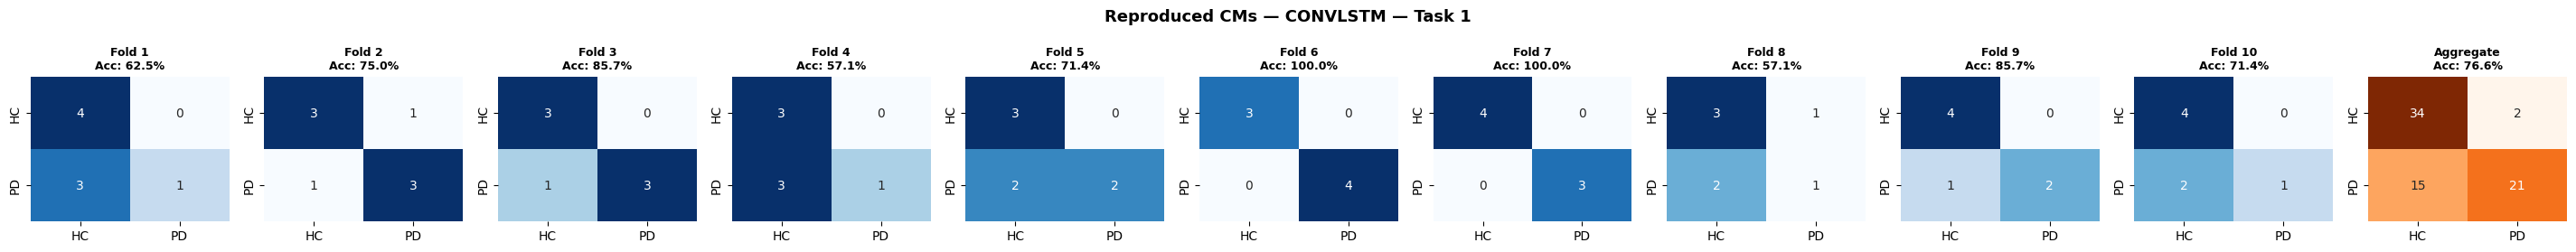


Reproducing FLIPFLOP — Task 1
  Fold  1: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 1 ---
  N_test=8 | Acc=62.5%  Prec=100.0%  Rec=25.0%  F1=40.0%
  CM:           HC    PD
        HC      4     0
        PD      3     1
  Fold  2: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 2 ---
  N_test=8 | Acc=62.5%  Prec=57.1%  Rec=100.0%  F1=72.7%
  CM:           HC    PD
        HC      1     3
        PD      0     4
  Fold  3: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 3 ---
  N_test=7 | Acc=85.7%  Prec=100.0%  Rec=75.0%  F1=85.7%
  CM:           HC    PD
        HC      3     0
        PD      1     3
  Fold  4: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 4 ---
  N_test=7 | Acc=57.1%  Prec=57.1%  Rec=100.0%  F1=72.7%
  CM:           HC    PD
        HC      0     3
        PD      0     4
  Fold  5: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 5 ---

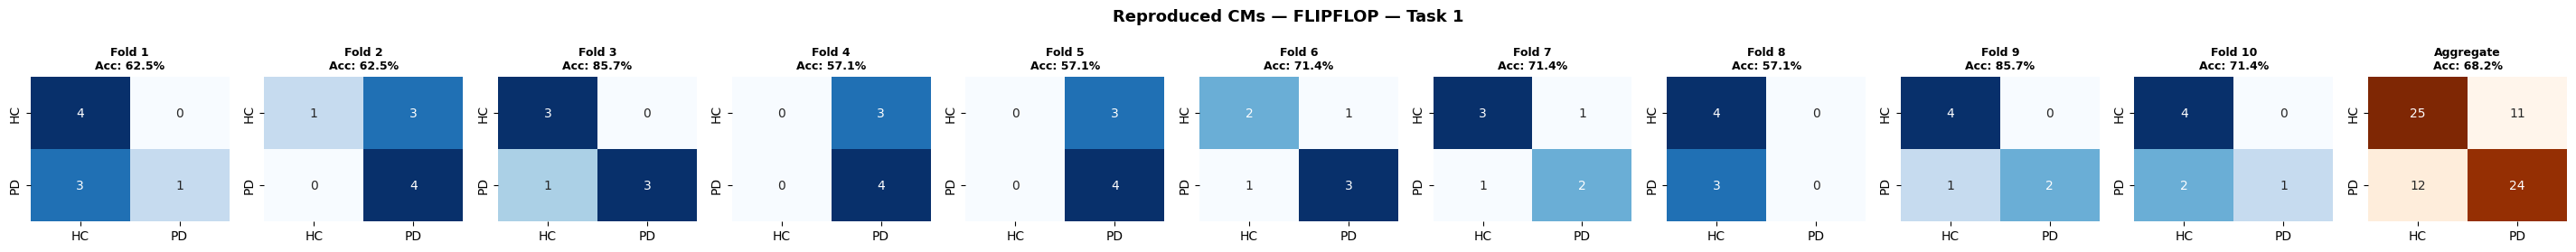


Reproducing VIT — Task 1
  Fold  1: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 1 ---
  N_test=8 | Acc=87.5%  Prec=100.0%  Rec=75.0%  F1=85.7%
  CM:           HC    PD
        HC      4     0
        PD      1     3
  Fold  2: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 2 ---
  N_test=8 | Acc=62.5%  Prec=57.1%  Rec=100.0%  F1=72.7%
  CM:           HC    PD
        HC      1     3
        PD      0     4
  Fold  3: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 3 ---
  N_test=7 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      3     0
        PD      0     4
  Fold  4: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 4 ---
  N_test=7 | Acc=71.4%  Prec=75.0%  Rec=75.0%  F1=75.0%
  CM:           HC    PD
        HC      2     1
        PD      1     3
  Fold  5: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 5 ---
  

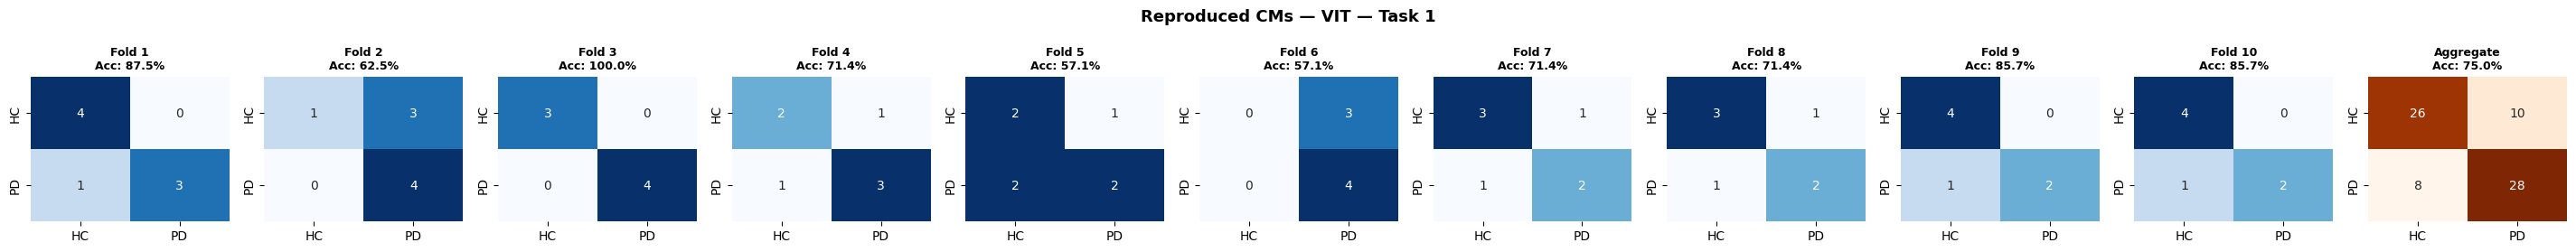


Reproducing CONVLSTM — Task 2
  Fold  1: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 1 ---
  N_test=8 | Acc=75.0%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     2
        PD      0     4
  Fold  2: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 2 ---
  N_test=8 | Acc=62.5%  Prec=66.7%  Rec=50.0%  F1=57.1%
  CM:           HC    PD
        HC      3     1
        PD      2     2
  Fold  3: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 3 ---
  N_test=8 | Acc=87.5%  Prec=100.0%  Rec=75.0%  F1=85.7%
  CM:           HC    PD
        HC      4     0
        PD      1     3
  Fold  4: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 4 ---
  N_test=8 | Acc=75.0%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     2
        PD      0     4
  Fold  5: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 5 ---
  N_test=8 | Acc=62.5%  Prec=66.7%  Rec=

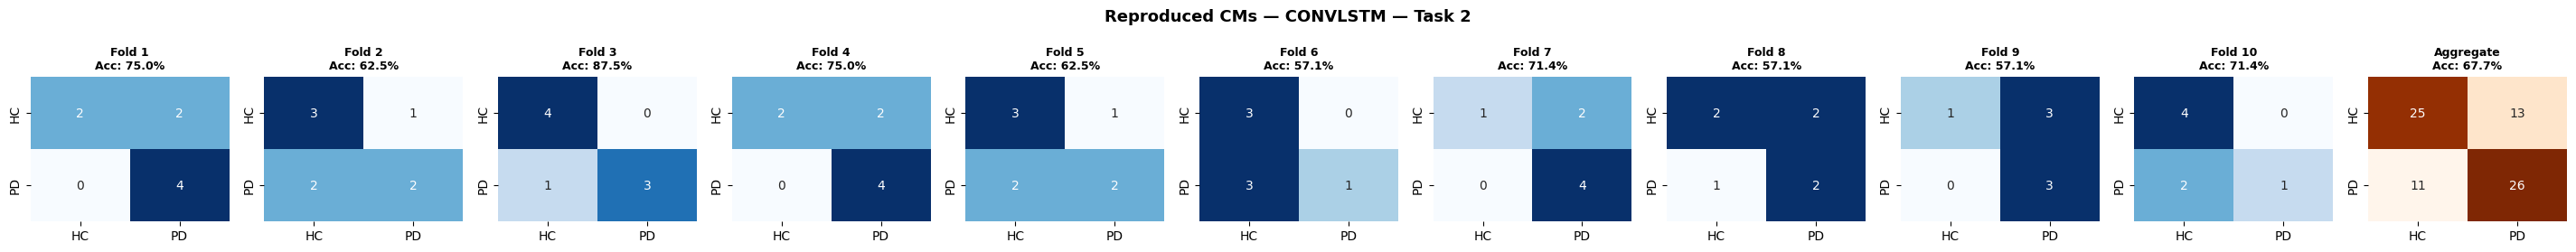


Reproducing FLIPFLOP — Task 2
  Fold  1: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 1 ---
  N_test=8 | Acc=75.0%  Prec=100.0%  Rec=50.0%  F1=66.7%
  CM:           HC    PD
        HC      4     0
        PD      2     2
  Fold  2: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 2 ---
  N_test=8 | Acc=50.0%  Prec=50.0%  Rec=100.0%  F1=66.7%
  CM:           HC    PD
        HC      0     4
        PD      0     4
  Fold  3: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 3 ---
  N_test=8 | Acc=75.0%  Prec=75.0%  Rec=75.0%  F1=75.0%
  CM:           HC    PD
        HC      3     1
        PD      1     3
  Fold  4: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 4 ---
  N_test=8 | Acc=62.5%  Prec=66.7%  Rec=50.0%  F1=57.1%
  CM:           HC    PD
        HC      3     1
        PD      2     2
  Fold  5: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 5 ---
 

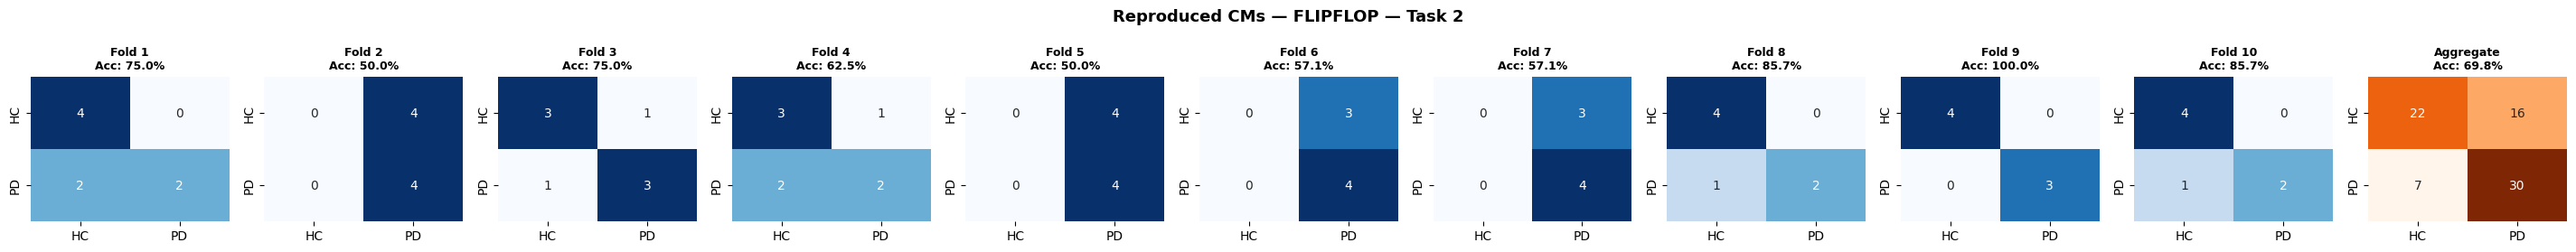


Reproducing VIT — Task 2
  Fold  1: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 1 ---
  N_test=8 | Acc=75.0%  Prec=100.0%  Rec=50.0%  F1=66.7%
  CM:           HC    PD
        HC      4     0
        PD      2     2
  Fold  2: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 2 ---
  N_test=8 | Acc=62.5%  Prec=66.7%  Rec=50.0%  F1=57.1%
  CM:           HC    PD
        HC      3     1
        PD      2     2
  Fold  3: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 3 ---
  N_test=8 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      4     0
        PD      0     4
  Fold  4: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 4 ---
  N_test=8 | Acc=75.0%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     2
        PD      0     4
  Fold  5: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 5 ---
  

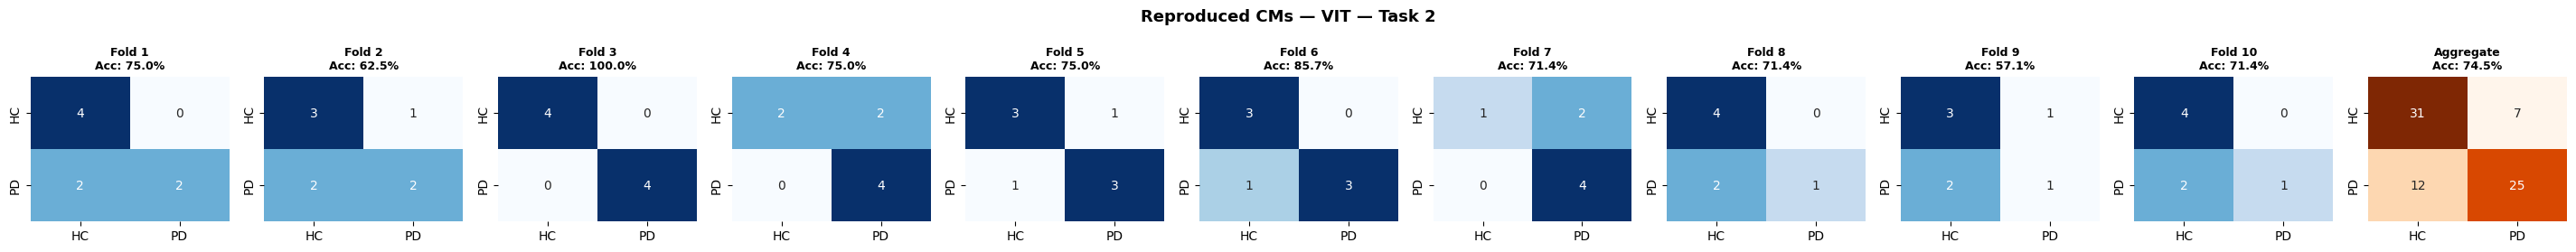


Reproducing CONVLSTM — Task 3
  Fold  1: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 1 ---
  N_test=8 | Acc=62.5%  Prec=66.7%  Rec=50.0%  F1=57.1%
  CM:           HC    PD
        HC      3     1
        PD      2     2
  Fold  2: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 2 ---
  N_test=8 | Acc=75.0%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     2
        PD      0     4
  Fold  3: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 3 ---
  N_test=8 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      4     0
        PD      0     4
  Fold  4: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 4 ---
  N_test=8 | Acc=75.0%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     2
        PD      0     4
  Fold  5: layout=B_npy  ckpt=best_model.keras  cache-match=N/A

  --- Fold 5 ---
  N_test=8 | Acc=75.0%  Prec=100.0%  

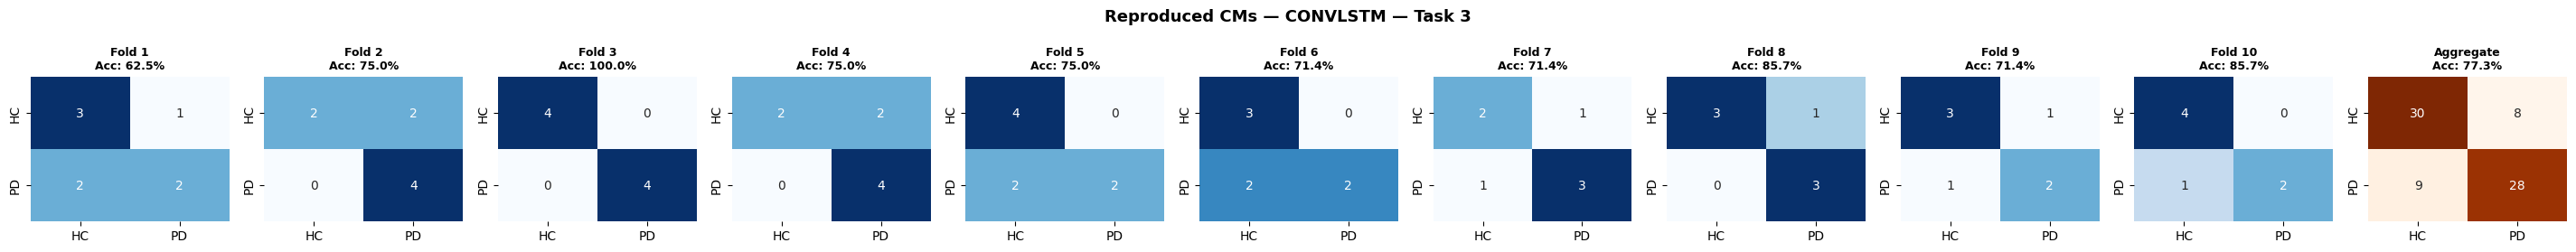


Reproducing FLIPFLOP — Task 3
  Fold  1: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 1 ---
  N_test=8 | Acc=50.0%  Prec=50.0%  Rec=100.0%  F1=66.7%
  CM:           HC    PD
        HC      0     4
        PD      0     4
  Fold  2: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 2 ---
  N_test=8 | Acc=50.0%  Prec=0.0%  Rec=0.0%  F1=0.0%
  CM:           HC    PD
        HC      4     0
        PD      4     0
  Fold  3: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 3 ---
  N_test=8 | Acc=50.0%  Prec=50.0%  Rec=100.0%  F1=66.7%
  CM:           HC    PD
        HC      0     4
        PD      0     4
  Fold  4: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 4 ---
  N_test=8 | Acc=50.0%  Prec=0.0%  Rec=0.0%  F1=0.0%
  CM:           HC    PD
        HC      4     0
        PD      4     0
  Fold  5: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 5 ---
  N_tes

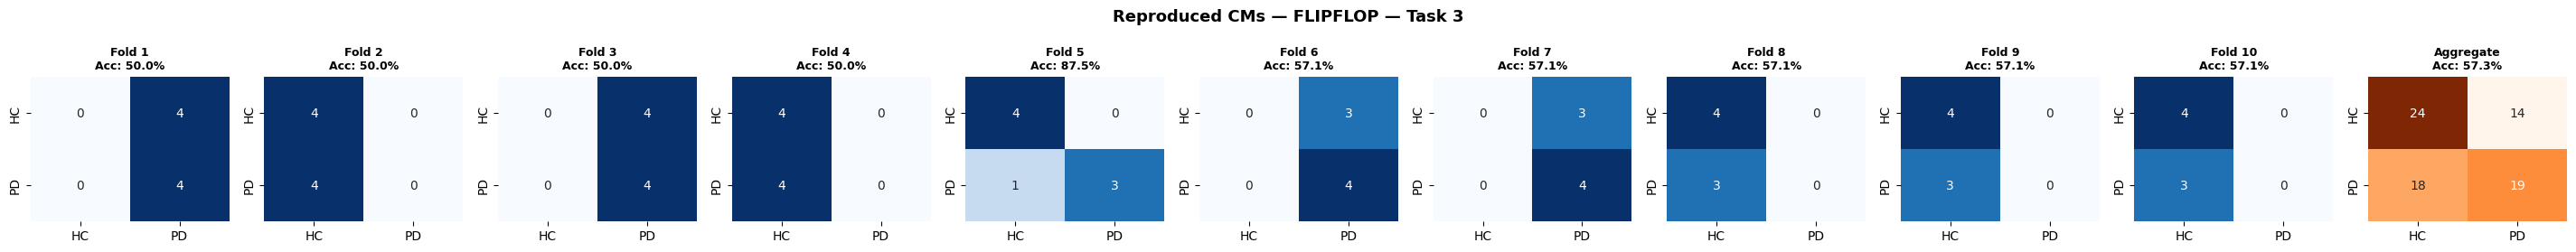


Reproducing VIT — Task 3
  Fold  1: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 1 ---
  N_test=8 | Acc=62.5%  Prec=100.0%  Rec=25.0%  F1=40.0%
  CM:           HC    PD
        HC      4     0
        PD      3     1
  Fold  2: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 2 ---
  N_test=8 | Acc=50.0%  Prec=50.0%  Rec=100.0%  F1=66.7%
  CM:           HC    PD
        HC      0     4
        PD      0     4
  Fold  3: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 3 ---
  N_test=8 | Acc=87.5%  Prec=80.0%  Rec=100.0%  F1=88.9%
  CM:           HC    PD
        HC      3     1
        PD      0     4
  Fold  4: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 4 ---
  N_test=8 | Acc=75.0%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     2
        PD      0     4
  Fold  5: layout=A_pkl  ckpt=best_model.keras  cache-match=100.0% [OK]

  --- Fold 5 ---
  N_

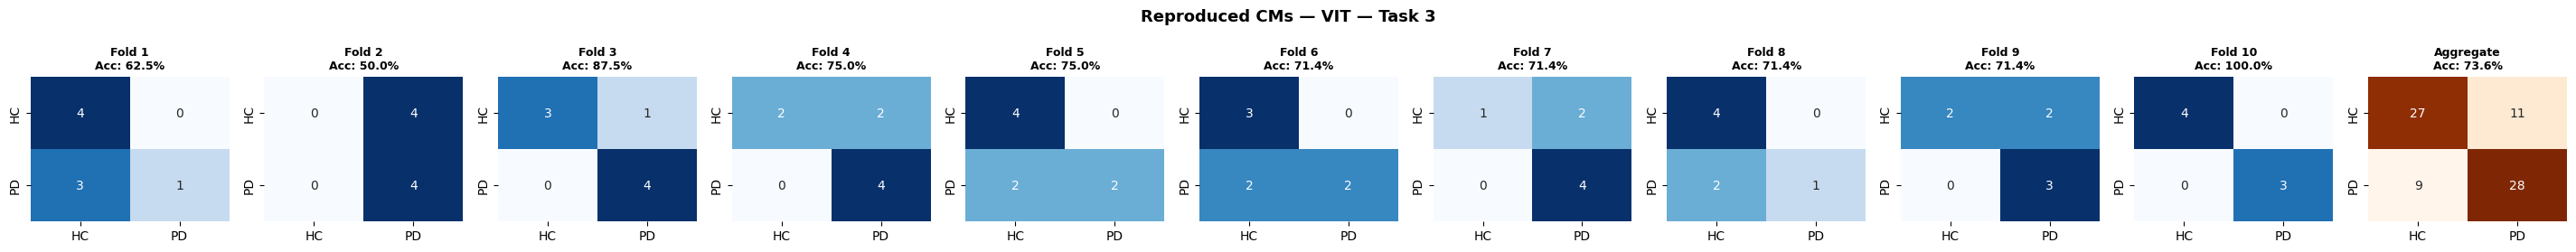



GRAND COMPARISON (Reproduced) — Handwriting PD Classification
  Task   Model         Folds   Mean Acc    Std Acc    Mean F1     Std F1
  ----------------------------------------------------------------------
  T1     convlstm         10      76.6%      15.1%      67.7%      22.9%
  T1     flipflop         10      68.2%      10.4%      61.6%      24.3%
  T1     vit              10      75.0%      13.6%      75.7%      11.2%
  ----------------------------------------------------------------------
  T2     convlstm         10      67.7%       9.6%      65.4%      14.6%
  T2     flipflop         10      69.8%      16.2%      73.8%      10.9%
  T2     vit              10      74.5%      11.2%      68.5%      18.0%
  ----------------------------------------------------------------------
  T3     convlstm         10      77.3%      10.0%      75.8%      11.6%
  T3     flipflop         10      57.3%      10.6%      36.5%      36.8%
  T3     vit              10      73.6%      12.6%      71.4

In [6]:
# ============================================================
# Reproduce Handwriting PD Classification Results — STANDALONE
# Handles TWO folder layouts:
#
#   Layout A  (FlipFlop, ViT):
#     fold_<model>_<k>/
#       best_model.keras
#       test_data.pkl       (X_test, y_test, [input_shape, ids, idx, ...])
#       predictions.pkl     (y_pred, y_true, [test_ids])      [optional]
#
#   Layout B  (ConvLSTM):
#     fold_convlstm_<k>/
#       last_model.h5  (or best_model.keras / .h5 if present)
#       X_test.npy
#       y_test.npy
#       test_indices.npy        [optional]
#       test_subject_ids.json   [optional]
#       metadata.json           [optional]
#
# Supported models: ConvLSTM2D, FlipFlop2D, ViT
# ============================================================

import os
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — edit these
# ============================================================
ROOT_MODEL_FOLDER = Path("./")
TASKS_TO_RUN      = [1, 2, 3]
MODELS_TO_RUN     = ['convlstm', 'flipflop', 'vit']
N_FOLDS           = 10

print(f"TF version   : {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Root folder  : {ROOT_MODEL_FOLDER.resolve()}")


# ============================================================
# CUSTOM LAYERS — needed to deserialize FlipFlop / ViT
# ============================================================
class FlipFlopCell2D(layers.Layer):
    def __init__(self, filters, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv_xj = layers.Conv2D(self.filters, self.kernel_size, padding='same')
        self.conv_hj = layers.Conv2D(self.filters, self.kernel_size, padding='same')
        self.conv_xk = layers.Conv2D(self.filters, self.kernel_size, padding='same')
        self.conv_hk = layers.Conv2D(self.filters, self.kernel_size, padding='same')
        super().build(input_shape)

    def call(self, inputs, states):
        h_prev = states[0]
        j = tf.nn.sigmoid(self.conv_xj(inputs) + self.conv_hj(h_prev))
        k = tf.nn.sigmoid(self.conv_xk(inputs) + self.conv_hk(h_prev))
        h_new = (1.0 - h_prev) * j + (1.0 - k) * h_prev
        return h_new, [h_new]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'filters': self.filters, 'kernel_size': self.kernel_size})
        return cfg


class FlipFlop2D(layers.Layer):
    def __init__(self, filters, kernel_size=3, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.return_sequences = return_sequences
        self.cell = FlipFlopCell2D(filters, kernel_size)

    def build(self, input_shape):
        self.cell.build(input_shape[2:])
        super().build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        height     = tf.shape(inputs)[2]
        width      = tf.shape(inputs)[3]
        h_t = tf.zeros((batch_size, height, width, self.filters))
        outputs = []
        for t in range(inputs.shape[1]):
            x_t = inputs[:, t, :, :, :]
            h_t, _ = self.cell(x_t, [h_t])
            outputs.append(h_t)
        if self.return_sequences:
            return tf.stack(outputs, axis=1)
        return h_t

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'filters': self.filters, 'kernel_size': self.kernel_size,
                    'return_sequences': self.return_sequences})
        return cfg


class CLSTokenAndPosEmbed(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        init = keras.initializers.TruncatedNormal(stddev=0.02)
        self.cls_token = self.add_weight(name="cls_token",
                                         shape=(1, 1, self.embed_dim),
                                         initializer=init, trainable=True)
        self.pos_embed = self.add_weight(name="pos_embed",
                                         shape=(1, self.num_patches + 1, self.embed_dim),
                                         initializer=init, trainable=True)
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x = tf.concat([cls, x], axis=1)
        x = x + self.pos_embed
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_patches": self.num_patches, "embed_dim": self.embed_dim})
        return cfg


class ExtractCLS(layers.Layer):
    def call(self, x):
        return x[:, 0, :]


CUSTOM_OBJECTS = {
    'FlipFlop2D':          FlipFlop2D,
    'FlipFlopCell2D':      FlipFlopCell2D,
    'CLSTokenAndPosEmbed': CLSTokenAndPosEmbed,
    'ExtractCLS':          ExtractCLS,
}


# ============================================================
# FOLD I/O — handle both layouts
# ============================================================
def _find_checkpoint(fold_dir):
    """Pick the best available checkpoint, in order of preference."""
    candidates = [
        fold_dir / "best_model.keras",
        fold_dir / "best_model.h5",
        fold_dir / "last_model.keras",
        fold_dir / "last_model.h5",
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"No model checkpoint in {fold_dir} "
                            f"(looked for best/last .keras/.h5)")


def _load_test_data(fold_dir):
    """
    Load test data using whichever layout exists.
    Returns dict with at least: X_test, y_test, and optionally test_ids.
    """
    pkl_path = fold_dir / "test_data.pkl"
    if pkl_path.exists():
        # Layout A — FlipFlop / ViT
        with open(pkl_path, 'rb') as f:
            td = pickle.load(f)
        return {
            'X_test':   np.asarray(td['X_test']),
            'y_test':   np.asarray(td['y_test']),
            'test_ids': td.get('test_ids'),
            'layout':   'A_pkl',
        }

    # Layout B — ConvLSTM (npy + json)
    x_npy = fold_dir / "X_test.npy"
    y_npy = fold_dir / "y_test.npy"
    if x_npy.exists() and y_npy.exists():
        out = {
            'X_test': np.load(x_npy),
            'y_test': np.load(y_npy),
            'layout': 'B_npy',
        }
        ids_json = fold_dir / "test_subject_ids.json"
        if ids_json.exists():
            with open(ids_json, 'r') as f:
                out['test_ids'] = json.load(f)
        return out

    raise FileNotFoundError(
        f"No test data in {fold_dir} "
        f"(needed test_data.pkl OR X_test.npy + y_test.npy)"
    )


def _load_cached_predictions(fold_dir):
    """
    Optional: return cached y_pred for cross-checking.
    Handles both predictions.pkl (Layout A) and predictions.npy (if present).
    """
    pkl = fold_dir / "predictions.pkl"
    if pkl.exists():
        with open(pkl, 'rb') as f:
            d = pickle.load(f)
        return np.asarray(d.get('y_pred'))
    npy = fold_dir / "predictions.npy"
    if npy.exists():
        return np.load(npy)
    return None


# ============================================================
# CORE REPRODUCTION
# ============================================================
def reproduce_fold(model_type, task, fold):
    """Reproduce one fold. Returns (preds, labels, n_test, layout)."""
    task_dir = ROOT_MODEL_FOLDER / f"models_{model_type}_task_v2{task}"
    fold_dir = task_dir / f"fold_{model_type}_{fold}"

    ckpt   = _find_checkpoint(fold_dir)
    td     = _load_test_data(fold_dir)
    X_test = td['X_test']
    y_test = td['y_test']

    model  = keras.models.load_model(str(ckpt), custom_objects=CUSTOM_OBJECTS)
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

    return np.array(y_pred), np.array(y_test), len(y_test), td['layout'], ckpt.name


def reproduce_task(model_type, task, verify_against_cache=True):
    """Reproduce all folds for a (model, task) combo."""
    print(f"\n{'='*65}")
    print(f"Reproducing {model_type.upper()} — Task {task}")
    print(f"{'='*65}")

    task_dir = ROOT_MODEL_FOLDER / f"models_{model_type}_task_v2{task}"
    if not task_dir.exists():
        raise FileNotFoundError(f"No task dir: {task_dir}")

    fold_metrics, all_preds, all_labels, fold_n_test = [], [], [], []

    for fold in range(1, N_FOLDS + 1):
        try:
            preds, lbls, n_test, layout, ckpt_name = reproduce_fold(
                model_type, task, fold
            )
        except FileNotFoundError as e:
            print(f"  [SKIP] Fold {fold}: {e}")
            continue

        # Cross-check vs. cached preds if available
        if verify_against_cache:
            fold_dir = task_dir / f"fold_{model_type}_{fold}"
            cached = _load_cached_predictions(fold_dir)
            if cached is not None and len(cached) == len(preds):
                match = (cached == preds).mean() * 100
                flag  = "OK" if match == 100.0 else "WARN"
                print(f"  Fold {fold:2d}: layout={layout}  ckpt={ckpt_name}  "
                      f"cache-match={match:.1f}% [{flag}]")
            else:
                print(f"  Fold {fold:2d}: layout={layout}  ckpt={ckpt_name}  "
                      f"cache-match=N/A")
        else:
            print(f"  Fold {fold:2d}: layout={layout}  ckpt={ckpt_name}")

        acc  = accuracy_score(lbls, preds)
        prec = precision_score(lbls, preds, zero_division=0)
        rec  = recall_score(lbls, preds, zero_division=0)
        f1   = f1_score(lbls, preds, zero_division=0)
        fold_metrics.append({'fold': fold, 'acc': acc, 'prec': prec,
                             'rec': rec, 'f1': f1})
        all_preds.extend(preds)
        all_labels.extend(lbls)
        fold_n_test.append(n_test)

        cm = confusion_matrix(lbls, preds)
        print(f"\n  --- Fold {fold} ---")
        print(f"  N_test={len(lbls)} | Acc={acc*100:.1f}%  "
              f"Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  F1={f1*100:.1f}%")
        print(f"  CM:           HC    PD")
        print(f"        HC   {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"        PD   {cm[1,0]:4d}  {cm[1,1]:4d}")

    return {
        'metrics':     fold_metrics,
        'all_preds':   np.array(all_preds),
        'all_labels':  np.array(all_labels),
        'fold_n_test': fold_n_test,
    }


# ============================================================
# SUMMARY + PLOTTING
# ============================================================
def print_summary(results, model_type, task):
    print(f"\n{'='*55}")
    print(f"Reproduction Summary — {model_type.upper()} — Task {task}")
    print(f"{'='*55}")
    if not results['metrics']:
        print("  (no folds reproduced)")
        return

    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for m in results['metrics']:
        print(f"  {m['fold']:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")

    accs = [m['acc']  for m in results['metrics']]
    pres = [m['prec'] for m in results['metrics']]
    recs = [m['rec']  for m in results['metrics']]
    f1s  = [m['f1']   for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(pres)*100:>7.1f}% "
          f"{np.mean(recs)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}%  {np.std(pres)*100:>7.1f}%  "
          f"{np.std(recs)*100:>7.1f}%  {np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(results, model_type, task, save_dir=None):
    n_folds_done = len(results['metrics'])
    if n_folds_done == 0:
        return

    n_cols = n_folds_done + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(2.6 * n_cols, 2.8))
    if n_cols == 1:
        axes = [axes]
    fig.suptitle(f'Reproduced CMs — {model_type.upper()} — Task {task}',
                 fontsize=13, fontweight='bold')

    # Use the n_test we already collected — no need to re-open files
    start = 0
    for i, m in enumerate(results['metrics']):
        n_test = results['fold_n_test'][i]
        end    = start + n_test
        cm = confusion_matrix(results['all_labels'][start:end],
                              results['all_preds'][start:end])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        axes[i].set_title(f"Fold {m['fold']}\nAcc: {m['acc']*100:.1f}%",
                          fontsize=9, fontweight='bold')
        start = end

    cm_all  = confusion_matrix(results['all_labels'], results['all_preds'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=axes[-1],
                cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
    axes[-1].set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%",
                       fontsize=9, fontweight='bold')

    plt.tight_layout()
    if save_dir is not None:
        out = Path(save_dir) / f"{model_type}_task{task}_reproduced_cm.png"
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Saved: {out}")
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    grand = {}

    for task in TASKS_TO_RUN:
        for mt in MODELS_TO_RUN:
            try:
                results = reproduce_task(mt, task, verify_against_cache=True)
                if results['metrics']:
                    print_summary(results, mt, task)
                    plot_confusion_matrices(results, mt, task,
                                            save_dir=ROOT_MODEL_FOLDER)
                    grand[(task, mt)] = results
            except FileNotFoundError as e:
                print(f"\n[SKIP] {mt} / Task {task}: {e}")

    # ============================================================
    # GRAND COMPARISON TABLE
    # ============================================================
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON (Reproduced) — Handwriting PD Classification")
    print(f"{'='*75}")
    print(f"  {'Task':<6} {'Model':<12} {'Folds':>6} {'Mean Acc':>10} "
          f"{'Std Acc':>10} {'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*70}")
    for task in TASKS_TO_RUN:
        for mt in MODELS_TO_RUN:
            if (task, mt) not in grand:
                continue
            res  = grand[(task, mt)]
            accs = [m['acc'] for m in res['metrics']]
            f1s  = [m['f1']  for m in res['metrics']]
            print(f"  T{task:<5} {mt:<12} {len(accs):>6} "
                  f"{np.mean(accs)*100:>9.1f}% {np.std(accs)*100:>9.1f}% "
                  f"{np.mean(f1s)*100:>9.1f}% {np.std(f1s)*100:>9.1f}%")
        print(f"  {'-'*70}")